# Predicting which Hogwarts house Harry Potter Characters belong to

In [90]:
import pandas as pd
import numpy as np
import scipy.stats as stats

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA





# Download the data

In [91]:
# Load the CSV file for the training dataset
data = pd.read_csv('harry_potter_1000_students.csv')
df = pd.DataFrame(data)

df

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw
...,...,...,...,...,...,...,...,...,...,...
995,Half-blood,7,10,3,7,1,1,3,8,Ravenclaw
996,Pure-blood,7,3,2,7,8,6,7,7,Slytherin
997,Half-blood,5,10,5,3,3,5,7,10,Ravenclaw
998,Half-blood,5,6,10,4,4,6,2,4,Hufflepuff


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Blood Status         1000 non-null   object
 1   Bravery              1000 non-null   int64 
 2   Intelligence         1000 non-null   int64 
 3   Loyalty              1000 non-null   int64 
 4   Ambition             1000 non-null   int64 
 5   Dark Arts Knowledge  1000 non-null   int64 
 6   Quidditch Skills     1000 non-null   int64 
 7   Dueling Skills       1000 non-null   int64 
 8   Creativity           1000 non-null   int64 
 9   House                1000 non-null   object
dtypes: int64(8), object(2)
memory usage: 78.3+ KB


In [93]:
# Check if there are any missing values in the DataFrame
has_missing = data.isnull().values.any()
print("Are there any missing values?", has_missing)


# Only show columns with missing values
df.isnull().sum()[df.isnull().sum() > 0]


Are there any missing values? False


Series([], dtype: int64)

In [94]:
# Check both at once
non_pureblood_slytherin = df[(df['Blood Status'].isin(['Muggle-born', 'Half-blood'])) & 
                              (df['House'] == 'Slytherin')]
print(f"Non-purebloods in Slytherin: {len(non_pureblood_slytherin)}")

Non-purebloods in Slytherin: 177


### normal dataset

In [95]:
# Prepare features and target
# Encode Blood Status (categorical feature)
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

# Select features (all numeric columns except House)
feature_cols = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                'Dueling Skills', 'Creativity']

X = df[feature_cols].values
y = df['House'].values


### politically-correct-only attributes

In [67]:
# Prepare features and target
# Encode Blood Status (categorical feature)
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

# Select features (all numeric columns except House)
feature_cols = ['Bravery', 'Intelligence', 'Loyalty', 
                'Ambition']

X = df[feature_cols].values
y = df['House'].values


In [96]:
print("\n" + "="*60)
print("HOUSE DISTRIBUTION IN ORIGINAL DATASET")
print("="*60)

# Show class distribution BEFORE split
unique_orig, counts_orig = np.unique(y, return_counts=True)
for house, count in zip(unique_orig, counts_orig):
    print(f"  {house:12s}: {count:3d} ({count/len(y)*100:.1f}%)")


HOUSE DISTRIBUTION IN ORIGINAL DATASET
  Gryffindor  : 226 (22.6%)
  Hufflepuff  : 251 (25.1%)
  Ravenclaw   : 258 (25.8%)
  Slytherin   : 265 (26.5%)


# Splitting data into train-test-split

In [97]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [98]:
X_train

array([[ 2,  1,  7, ...,  6,  3,  9],
       [ 0,  2,  1, ..., 10,  8,  4],
       [ 1,  7,  7, ...,  9, 10,  3],
       ...,
       [ 1,  5,  4, ...,  6,  9,  4],
       [ 2,  3,  4, ...,  5,  2,  7],
       [ 0,  2,  4, ...,  5,  7,  5]], shape=(700, 9))

# Base Classifier

In [99]:
print("\n" + "="*60)
print("HOUSE DISTRIBUTION AFTER TRAIN-TEST SPLIT")
print("="*60)

# Show class distribution
print("\nTraining set distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for house, count in zip(unique, counts):
    print(f"  {house:12s}: {count:3d} ({count/len(y_train)*100:.1f}%)")

print("\nTest set distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for house, count in zip(unique_test, counts_test):
    print(f"  {house:12s}: {count:3d} ({count/len(y_test)*100:.1f}%)")

# Create and train majority class classifier
print("\n" + "="*60)
print("MAJORITY CLASS CLASSIFIER")
print("="*60)

majority_clf = DummyClassifier(strategy='most_frequent', random_state=42)
majority_clf.fit(X_train, y_train)

# Make predictions
y_pred = majority_clf.predict(X_test)

# Find the majority class
majority_house = unique[np.argmax(counts)]
print(f"\nMajority House: {majority_house}")
print(f"Strategy: Always predict '{majority_house}'")

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")



HOUSE DISTRIBUTION AFTER TRAIN-TEST SPLIT

Training set distribution:
  Gryffindor  : 158 (22.6%)
  Hufflepuff  : 176 (25.1%)
  Ravenclaw   : 181 (25.9%)
  Slytherin   : 185 (26.4%)

Test set distribution:
  Gryffindor  :  68 (22.7%)
  Hufflepuff  :  75 (25.0%)
  Ravenclaw   :  77 (25.7%)
  Slytherin   :  80 (26.7%)

MAJORITY CLASS CLASSIFIER

Majority House: Slytherin
Strategy: Always predict 'Slytherin'

Accuracy: 0.2667 (26.67%)


# Decision Tree

In [100]:
# Train Decision Tree Classifier with Hyperparameter Tuning
print("\n" + "="*60)
print("DECISION TREE WITH HYPERPARAMETER TUNING")
print("="*60)

# Define parameter distribution for Decision Tree
dt_param_dist = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_features': ['sqrt', 'log2', None]
}

print("\nSearching for best hyperparameters for Decision Tree...")
print("Parameter space:")
for param, values in dt_param_dist.items():
    print(f"  {param}: {values}")

# Create base Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)

# Perform RandomizedSearchCV
dt_random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=dt_param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

dt_random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in dt_random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {dt_random_search.best_score_:.4f} ({dt_random_search.best_score_*100:.2f}%)")

# Use the best model
dt_clf = dt_random_search.best_estimator_

# Make predictions
y_pred_dt = dt_clf.predict(X_test)

# Evaluate Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Test Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
print("-"*60)
houses = sorted(np.unique(y))
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=houses)
print(f"\n{'':12s}", end='')
for h in houses:
    print(f"{h:12s}", end='')
print()
for i, h in enumerate(houses):
    print(f"{h:12s}", end='')
    for j in range(len(houses)):
        print(f"{cm_dt[i,j]:12d}", end='')
    print()

# Feature importance for Decision Tree
print("\n" + "-"*60)
print("Decision Tree Feature Importance:")
print("-"*60)
feature_names = feature_cols
dt_importances = dt_clf.feature_importances_
dt_indices = np.argsort(dt_importances)[::-1]

for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[dt_indices[i]]:15s}: {dt_importances[dt_indices[i]]:.4f}")



DECISION TREE WITH HYPERPARAMETER TUNING

Searching for best hyperparameters for Decision Tree...
Parameter space:
  max_depth: [3, 5, 7, 10, 15, 20, None]
  min_samples_split: [2, 5, 10, 15, 20]
  min_samples_leaf: [1, 2, 4, 8, 10]
  criterion: ['gini', 'entropy']
  splitter: ['best', 'random']
  max_features: ['sqrt', 'log2', None]
Fitting 3 folds for each of 10 candidates, totalling 30 fits



Best parameters found:
  splitter: best
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: None
  max_depth: 20
  criterion: gini

Best cross-validation score: 0.9871 (98.71%)

Decision Tree Test Accuracy: 0.9900 (99.00%)

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

  Gryffindor       1.00      0.99      0.99        68
  Hufflepuff       0.97      1.00      0.99        75
   Ravenclaw       0.99      0.97      0.98        77
   Slytherin       1.00      1.00      1.00        80

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Confusion Matrix:
------------------------------------------------------------

            Gryffindor  Hufflepuff  Ravenclaw   Slytherin   
Gryffindor            67           0         

# Random Forest

In [ ]:
# Train Random Forest Classifier
print("\n" + "="*60)
print("RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*60)

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

print("\nSearching for best hyperparameters...")
print("Parameter space:")
for param, values in param_dist.items():
    print(f"  {param}: {values}")

# Create base Random Forest
rf_base = RandomForestClassifier(random_state=42)

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,  # Number of random combinations to try
    cv=3,  # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,  # Use all available cores
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {random_search.best_score_:.4f} ({random_search.best_score_*100:.2f}%)")

# Use the best model
rf_clf = random_search.best_estimator_

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")


# Feature importance
print("\n" + "-"*60)
print("Feature Importance:")
print("-"*60)
feature_names = feature_cols
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]:15s}: {importances[indices[i]]:.4f}")




RANDOM FOREST WITH HYPERPARAMETER TUNING

Searching for best hyperparameters...
Parameter space:
  n_estimators: [50, 100, 200, 300, 500]
  max_depth: [5, 10, 15, 20, 25, None]
  min_samples_split: [2, 5, 10, 15]
  min_samples_leaf: [1, 2, 4, 8]
  max_features: ['sqrt', 'log2', None]
  bootstrap: [True, False]
  criterion: ['gini', 'entropy']
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters found:
  n_estimators: 50
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: log2
  max_depth: 25
  criterion: entropy
  bootstrap: False

Best cross-validation score: 0.9943 (99.43%)

Random Forest Accuracy: 1.0000 (100.00%)

------------------------------------------------------------
Feature Importance:
------------------------------------------------------------
1. Dark Arts Knowledge: 0.2328
2. Dueling Skills : 0.2190
3. Loyalty        : 0.1318
4. Creativity     : 0.1272
5. Bravery        : 0.1054
6. Intelligence   : 0.0863
7. Ambition       : 0.0773
8. 

# Clustering

In [142]:
# K-MEANS CLUSTERING
print("\n" + "="*60)
print("K-MEANS CLUSTERING (UNSUPERVISED)")
print("="*60)

# Prepare features for clustering (only numerical attributes, no Blood Status)
cluster_features = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 
                    'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills', 'Creativity']

X_cluster = df[cluster_features].values

# Standardize features (important for K-means)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("\nFeatures used for clustering:")
for feat in cluster_features:
    print(f"  - {feat}")

# Apply K-means with 4 clusters (for 4 houses)
print("\nApplying K-means with 4 clusters...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters

# Calculate clustering metrics
silhouette = silhouette_score(X_cluster_scaled, clusters)
ari = adjusted_rand_score(df['House'], clusters)

print(f"\nSilhouette Score: {silhouette:.4f} (higher is better, range: -1 to 1)")
print(f"Adjusted Rand Index: {ari:.4f} (measures similarity to true houses, range: -1 to 1)")

# Show cluster distribution
print("\n" + "-"*60)
print("Cluster Distribution:")
print("-"*60)
unique_clusters, cluster_counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique_clusters, cluster_counts):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Clusters vs Houses
print("\n" + "-"*60)
print("Cluster vs House Cross-tabulation:")
print("-"*60)
crosstab = pd.crosstab(df['Cluster'], df['House'], margins=True)
print(crosstab)

# Find which cluster corresponds to which house (based on majority)
print("\n" + "-"*60)
print("Cluster-to-House Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Cluster'].unique()):
    house_counts = df[df['Cluster'] == cluster]['House'].value_counts()
    majority_house = house_counts.index[0]
    majority_count = house_counts.iloc[0]
    total = len(df[df['Cluster'] == cluster])
    print(f"  Cluster {cluster} → {majority_house:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# Show cluster centers (average traits per cluster)
print("\n" + "-"*60)
print("Cluster Centers (Average Traits):")
print("-"*60)
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\n{'Feature':20s}", end='')
for i in range(4):
    print(f"Cluster {i:1d}  ", end='')
print()
print("-" * 60)
for i, feat in enumerate(cluster_features):
    print(f"{feat:20s}", end='')
    for j in range(4):
        print(f"{cluster_centers_original[j,i]:10.2f}", end='')
    print()

# Interpretation
print("\n" + "-"*60)
print("Clustering Interpretation:")
print("-"*60)
print(f"K-means found natural groupings in the data with {silhouette:.2f} silhouette score.")
print(f"The Adjusted Rand Index of {ari:.2f} shows how well clusters match actual houses.")
print("(ARI=1: perfect match, ARI=0: random, ARI<0: worse than random)")


K-MEANS CLUSTERING (UNSUPERVISED)

Features used for clustering:
  - Bravery
  - Intelligence
  - Loyalty
  - Ambition
  - Dark Arts Knowledge
  - Quidditch Skills
  - Dueling Skills
  - Creativity

Applying K-means with 4 clusters...

Silhouette Score: 0.3233 (higher is better, range: -1 to 1)
Adjusted Rand Index: 0.9973 (measures similarity to true houses, range: -1 to 1)

------------------------------------------------------------
Cluster Distribution:
------------------------------------------------------------
  Cluster 0: 265 students (26.5%)
  Cluster 1: 250 students (25.0%)
  Cluster 2: 226 students (22.6%)
  Cluster 3: 259 students (25.9%)

------------------------------------------------------------
Cluster vs House Cross-tabulation:
------------------------------------------------------------
House    Gryffindor  Hufflepuff  Ravenclaw  Slytherin   All
Cluster                                                    
0                 0           0          0        265   265
1  


PCA VISUALIZATION OF CLUSTERS


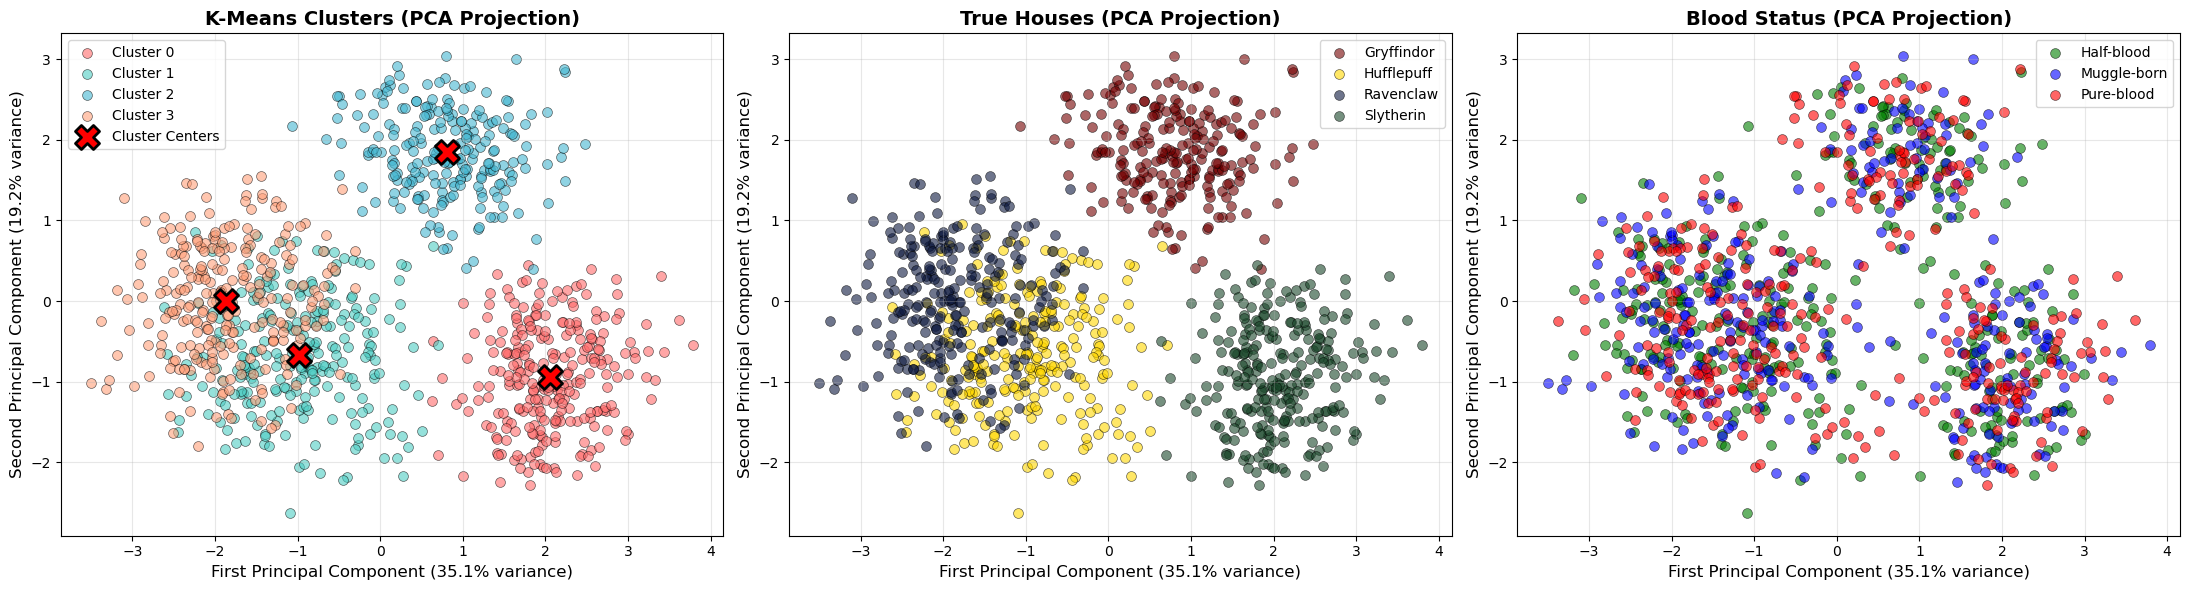

In [104]:
# Apply PCA to reduce to 2 dimensions for visualization
print("\n" + "="*60)
print("PCA VISUALIZATION OF CLUSTERS")
print("="*60)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Define colors for clusters, houses, and blood status
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}

# Plot 1: Colored by Cluster
ax1 = axes[0]
for cluster in range(4):
    mask = clusters == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[cluster], 
               label=f'Cluster {cluster}',
               alpha=0.6, 
               s=50,
               edgecolors='black',
               linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='red', 
           marker='X', 
           s=300, 
           edgecolors='black',
           linewidth=2,
           label='Cluster Centers',
           zorder=5)

ax1.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax1.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax1.set_title('K-Means Clusters (PCA Projection)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by True House
ax2 = axes[1]
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax2.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax2.set_title('True Houses (PCA Projection)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by Blood Status
ax3 = axes[2]
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax3.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax3.set_title('Blood Status (PCA Projection)', fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Clustering datapoints my way >:)


WEIGHTED K-MEANS WITH BLOOD STATUS EMPHASIS

Blood Status Weight: 500x
Other Features Weight: 1x each

Applying weighted K-means with 4 clusters...

Weighted Clustering Metrics:
  Silhouette Score: 1.0000
  Adjusted Rand Index (vs Houses): -0.0005

------------------------------------------------------------
Weighted Cluster Distribution:
------------------------------------------------------------
  Cluster 0: 313 students (31.3%)
  Cluster 1: 332 students (33.2%)
  Cluster 2: 355 students (35.5%)

------------------------------------------------------------
Weighted Cluster vs Blood Status:
------------------------------------------------------------


/Users/blazingsun88/miniconda3/envs/ml/lib/python3.14/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Blood Status      Half-blood  Muggle-born  Pure-blood   All
Weighted_Cluster                                           
0                          0          313           0   313
1                          0            0         332   332
2                        355            0           0   355
All                      355          313         332  1000

------------------------------------------------------------
Weighted Cluster vs House:
------------------------------------------------------------
House             Gryffindor  Hufflepuff  Ravenclaw  Slytherin   All
Weighted_Cluster                                                    
0                         62          74         86         91   313
1                         78          89         77         88   332
2                         86          88         95         86   355
All                      226         251        258        265  1000

------------------------------------------------------------
Cluster-to-Blo

IndexError: single positional indexer is out-of-bounds

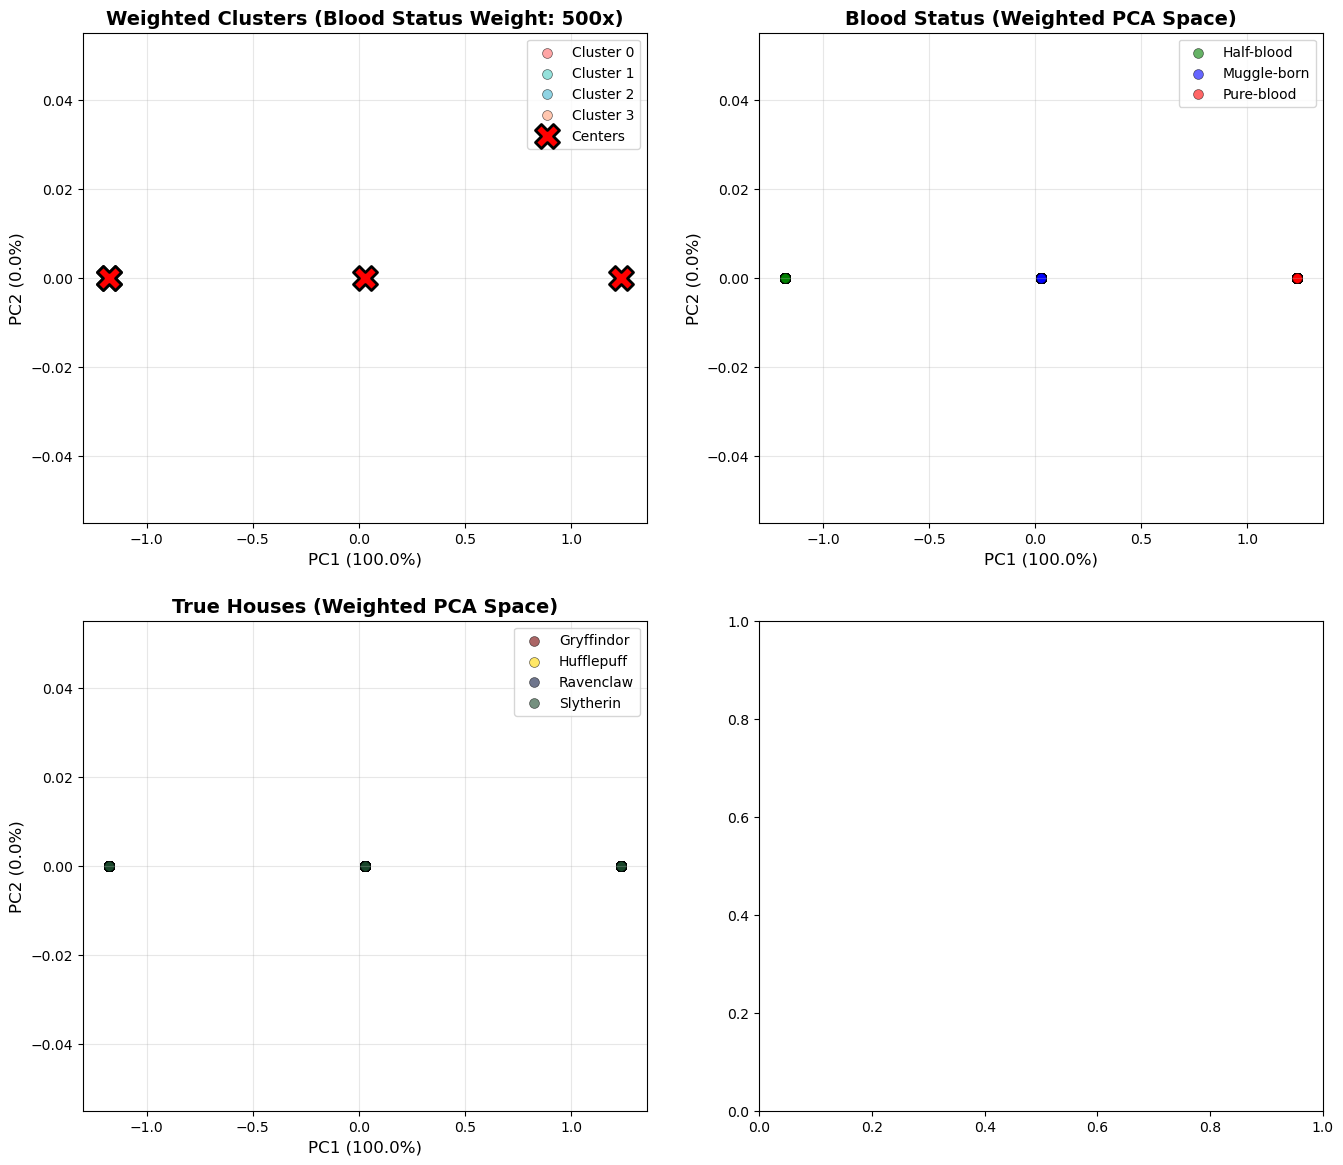

In [110]:
# WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("WEIGHTED K-MEANS WITH BLOOD STATUS EMPHASIS")
print("="*60)

# Prepare features with Blood Status encoded
cluster_features_weighted = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                              'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                              'Dueling Skills', 'Creativity']

X_weighted = df[cluster_features_weighted].values

# Define feature weights - HIGH weight on Blood Status
# You can adjust the blood_status_weight parameter
blood_status_weight = 500  # Try values like 1, 5, 10, 20, 50

feature_weights = np.array([
    blood_status_weight,  # Blood Status - HEAVILY WEIGHTED
    0,  # Bravery
    0,  # Intelligence
    0,  # Loyalty
    0,  # Ambition
    0,  # Dark Arts Knowledge
    0,  # Quidditch Skills
    0,  # Dueling Skills
    0   # Creativity
])

print(f"\nBlood Status Weight: {blood_status_weight}x")
print(f"Other Features Weight: 1x each")

# Apply weights by multiplying features
X_weighted_scaled = X_weighted * feature_weights

# Standardize the weighted features
scaler_weighted = StandardScaler()
X_weighted_scaled = scaler_weighted.fit_transform(X_weighted_scaled)

# Apply K-means
print("\nApplying weighted K-means with 4 clusters...")
kmeans_weighted = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_weighted = kmeans_weighted.fit_predict(X_weighted_scaled)

# Calculate metrics
silhouette_weighted = silhouette_score(X_weighted_scaled, clusters_weighted)
ari_weighted = adjusted_rand_score(df['House'], clusters_weighted)

print(f"\nWeighted Clustering Metrics:")
print(f"  Silhouette Score: {silhouette_weighted:.4f}")
print(f"  Adjusted Rand Index (vs Houses): {ari_weighted:.4f}")

# Add weighted cluster labels to dataframe
df['Weighted_Cluster'] = clusters_weighted

# Show cluster distribution
print("\n" + "-"*60)
print("Weighted Cluster Distribution:")
print("-"*60)
unique_clusters_w, cluster_counts_w = np.unique(clusters_weighted, return_counts=True)
for cluster, count in zip(unique_clusters_w, cluster_counts_w):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Weighted Clusters vs Blood Status
print("\n" + "-"*60)
print("Weighted Cluster vs Blood Status:")
print("-"*60)
crosstab_blood = pd.crosstab(df['Weighted_Cluster'], df['Blood Status'], margins=True)
print(crosstab_blood)

# Cross-tabulation: Weighted Clusters vs Houses
print("\n" + "-"*60)
print("Weighted Cluster vs House:")
print("-"*60)
crosstab_house = pd.crosstab(df['Weighted_Cluster'], df['House'], margins=True)
print(crosstab_house)

# Cluster-to-Blood Status mapping
print("\n" + "-"*60)
print("Cluster-to-Blood Status Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Weighted_Cluster'].unique()):
    blood_counts = df[df['Weighted_Cluster'] == cluster]['Blood Status'].value_counts()
    majority_blood = blood_counts.index[0]
    majority_count = blood_counts.iloc[0]
    total = len(df[df['Weighted_Cluster'] == cluster])
    print(f"  Cluster {cluster} → {majority_blood:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization (on weighted data)
pca_weighted = PCA(n_components=2, random_state=42)
X_pca_weighted = pca_weighted.fit_transform(X_weighted_scaled)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Define colors
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Weighted Clusters
ax1 = axes[0, 0]
for cluster in range(4):
    mask = clusters_weighted == cluster
    ax1.scatter(X_pca_weighted[mask, 0], X_pca_weighted[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_weighted = pca_weighted.transform(kmeans_weighted.cluster_centers_)
ax1.scatter(centers_pca_weighted[:, 0], centers_pca_weighted[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)

ax1.set_xlabel(f'PC1 ({pca_weighted.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca_weighted.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax1.set_title(f'Weighted Clusters (Blood Status Weight: {blood_status_weight}x)', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = axes[0, 1]
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_weighted[mask, 0], X_pca_weighted[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'PC1 ({pca_weighted.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca_weighted.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax2.set_title('Blood Status (Weighted PCA Space)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = axes[1, 0]
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_weighted[mask, 0], X_pca_weighted[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'PC1 ({pca_weighted.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax3.set_ylabel(f'PC2 ({pca_weighted.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax3.set_title('True Houses (Weighted PCA Space)', fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Comparison of cluster purity
ax4 = axes[1, 1]

# Calculate cluster purity for blood status
cluster_purity = []
cluster_labels = []
for cluster in range(4):
    cluster_mask = df['Weighted_Cluster'] == cluster
    blood_in_cluster = df[cluster_mask]['Blood Status'].value_counts()
    purity = blood_in_cluster.iloc[0] / blood_in_cluster.sum() * 100
    cluster_purity.append(purity)
    cluster_labels.append(f"C{cluster}\n{blood_in_cluster.index[0][:4]}")

bars = ax4.bar(range(4), cluster_purity, color=cluster_colors, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Cluster', fontsize=12)
ax4.set_ylabel('Blood Status Purity (%)', fontsize=12)
ax4.set_title('Cluster Purity by Blood Status', fontsize=14, fontweight='bold')
ax4.set_xticks(range(4))
ax4.set_xticklabels(cluster_labels)
ax4.set_ylim([0, 105])
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, purity) in enumerate(zip(bars, cluster_purity)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{purity:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Compare with original unweighted clustering
print("\n" + "="*60)
print("COMPARISON: WEIGHTED vs UNWEIGHTED CLUSTERING")
print("="*60)
print(f"\nUnweighted Clustering:")
print(f"  ARI vs Houses: {ari:.4f}")
print(f"  Silhouette Score: {silhouette:.4f}")

print(f"\nWeighted Clustering (Blood Status Weight: {blood_status_weight}x):")
print(f"  ARI vs Houses: {ari_weighted:.4f}")
print(f"  Silhouette Score: {silhouette_weighted:.4f}")

# Show how many students changed clusters
changed = np.sum(clusters != clusters_weighted)
print(f"\nStudents that changed cluster: {changed} ({changed/len(df)*100:.1f}%)")

print("\n" + "-"*60)
print("INTERPRETATION:")
print("-"*60)
print(f"With {blood_status_weight}x weight on Blood Status:")
print("  - Clusters now prioritize blood status grouping")
print("  - Check the 'Cluster Purity' bar chart to see blood status concentration")
print("  - Compare ARI scores to see alignment with houses vs blood status")
print("\nTry different weights (1, 5, 10, 20, 50) to see the effect!")


SLYTHERIN PROBABILITY ANALYSIS

Training Random Forest for probability estimation...
Model trained. Classes: ['Gryffindor' 'Hufflepuff' 'Ravenclaw' 'Slytherin']

Creating probability plots...


AttributeError: 'numpy.ndarray' object has no attribute 'scatter'

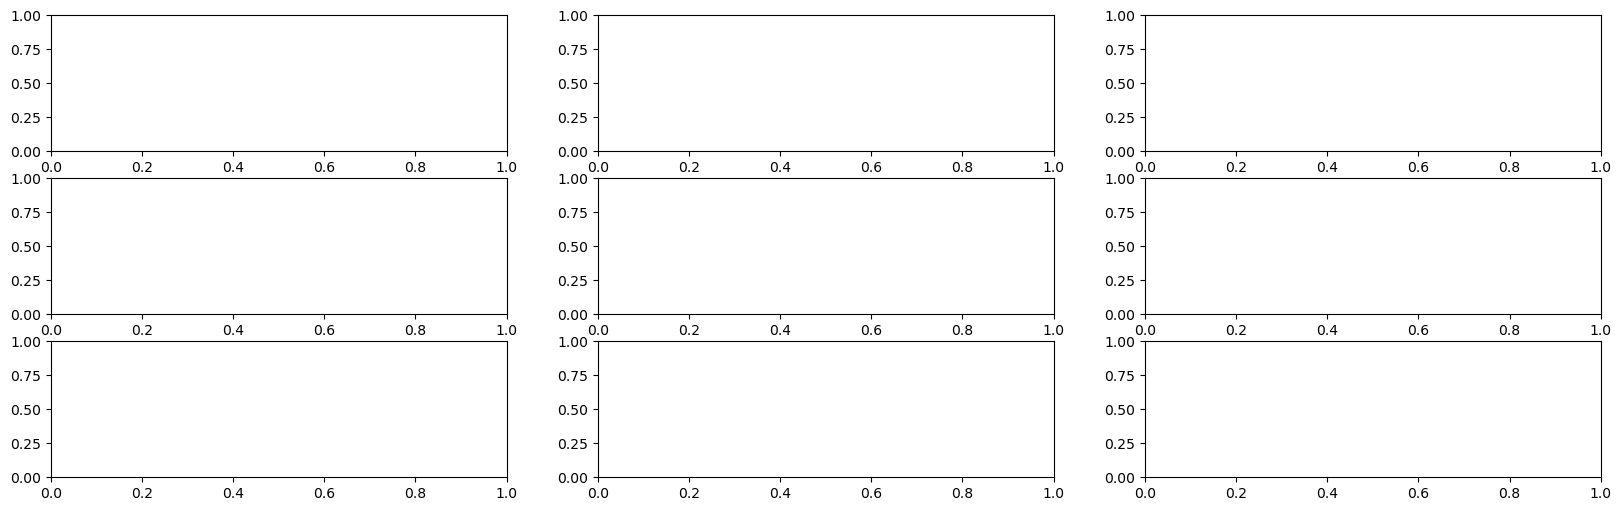

In [119]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.interpolate import make_interp_spline

# TRAIN A MODEL TO GET PROBABILITIES
print("\n" + "="*60)
print("SLYTHERIN PROBABILITY ANALYSIS")
print("="*60)

# Prepare features and target
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

feature_cols_prob = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                     'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                     'Dueling Skills', 'Creativity']

X_prob = df[feature_cols_prob].values
y_prob = df['House'].values

# Train a Random Forest to get probability estimates
print("\nTraining Random Forest for probability estimation...")
rf_prob = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=20)
rf_prob.fit(X_prob, y_prob)

# Get predicted probabilities for all houses
probs = rf_prob.predict_proba(X_prob)
house_names = rf_prob.classes_

# Get Slytherin probabilities
slytherin_idx = np.where(house_names == 'Slytherin')[0][0]
slytherin_probs = probs[:, slytherin_idx]

# Add to dataframe
df['Slytherin_Probability'] = slytherin_probs

print(f"Model trained. Classes: {house_names}")

# CREATE PLOTS FOR AMBITION, DARK ARTS KNOWLEDGE, DUELING SKILLS
print("\nCreating probability plots...")

features_to_plot = feature_cols_prob
fig, axes = plt.subplots(3, 3, figsize=(20, 6))

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    
    # Get feature values and corresponding Slytherin probabilities
    feature_values = df[feature].values
    probs_for_feature = df['Slytherin_Probability'].values
    
    # Calculate mean probability for each feature value
    unique_values = np.sort(df[feature].unique())
    mean_probs = []
    std_probs = []
    counts = []
    
    for val in unique_values:
        mask = feature_values == val
        mean_probs.append(probs_for_feature[mask].mean())
        std_probs.append(probs_for_feature[mask].std())
        counts.append(mask.sum())
    
    mean_probs = np.array(mean_probs)
    std_probs = np.array(std_probs)
    
    # Scatter plot: all individual data points
    ax.scatter(feature_values, probs_for_feature, 
              alpha=0.3, s=30, c='lightblue', edgecolors='none',
              label='Individual Students')
    
    # Line plot: mean probability with error bars
    ax.errorbar(unique_values, mean_probs, yerr=std_probs,
               fmt='o-', color='darkgreen', linewidth=2.5, 
               markersize=8, capsize=5, capthick=2,
               label='Mean ± Std', zorder=5)
    
    # Smooth trend line
    if len(unique_values) > 3:
        x_smooth = np.linspace(unique_values.min(), unique_values.max(), 300)
        spl = make_interp_spline(unique_values, mean_probs, k=min(3, len(unique_values)-1))
        y_smooth = spl(x_smooth)
        ax.plot(x_smooth, y_smooth, '--', color='red', linewidth=2, 
               alpha=0.7, label='Trend', zorder=4)
    
    # Formatting
    ax.set_xlabel(feature, fontsize=13, fontweight='bold')
    ax.set_ylabel('P(Slytherin)', fontsize=13, fontweight='bold')
    ax.set_title(f'{feature} vs Slytherin Probability', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([-0.05, 1.05])
    ax.legend(loc='best', fontsize=10)
    
    # Add sample size annotations at the bottom
    for i, (val, count) in enumerate(zip(unique_values, counts)):
        if i % 2 == 0:  # Show every other to avoid crowding
            ax.text(val, -0.02, f'n={count}', 
                   ha='center', va='top', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

# STATISTICAL SUMMARY
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

for feature in features_to_plot:
    print(f"\n{feature}:")
    print("-" * 40)
    
    # Group by feature value
    grouped = df.groupby(feature)['Slytherin_Probability'].agg(['mean', 'std', 'count'])
    print(grouped.to_string())
    
    # Correlation
    correlation = df[feature].corr(df['Slytherin_Probability'])
    print(f"\nCorrelation with Slytherin Probability: {correlation:.4f}")

# ADDITIONAL ANALYSIS: Combined effect
print("\n" + "="*60)
print("COMBINED EFFECT ANALYSIS")
print("="*60)

# Create bins for high/low values
df['High_Ambition'] = (df['Ambition'] >= 7).astype(int)
df['High_Dark_Arts'] = (df['Dark Arts Knowledge'] >= 7).astype(int)
df['High_Dueling'] = (df['Dueling Skills'] >= 7).astype(int)

# Analyze combinations
print("\nSlytherin Probability by Trait Combinations:")
print("-" * 60)

combinations = [
    (0, 0, 0, "Low All"),
    (1, 0, 0, "High Ambition Only"),
    (0, 1, 0, "High Dark Arts Only"),
    (0, 0, 1, "High Dueling Only"),
    (1, 1, 0, "High Ambition + Dark Arts"),
    (1, 0, 1, "High Ambition + Dueling"),
    (0, 1, 1, "High Dark Arts + Dueling"),
    (1, 1, 1, "High All Three"),
]

results = []
for amb, dark, duel, label in combinations:
    mask = (df['High_Ambition'] == amb) & \
           (df['High_Dark_Arts'] == dark) & \
           (df['High_Dueling'] == duel)
    
    if mask.sum() > 0:
        mean_prob = df.loc[mask, 'Slytherin_Probability'].mean()
        count = mask.sum()
        actual_slytherin = (df.loc[mask, 'House'] == 'Slytherin').sum()
        results.append((label, mean_prob, count, actual_slytherin))
        print(f"{label:30s}: P={mean_prob:.3f} (n={count:3d}, {actual_slytherin:3d} actual Slytherins)")

# Visualize combined effects
fig, ax = plt.subplots(figsize=(12, 6))

labels = [r[0] for r in results]
probs = [r[1] for r in results]
counts = [r[2] for r in results]

bars = ax.bar(range(len(labels)), probs, color='#1A472A', edgecolor='black', linewidth=1.5)

# Color gradient based on probability
for i, (bar, prob) in enumerate(zip(bars, probs)):
    bar.set_color(plt.cm.RdYlGn_r(prob))

ax.set_ylabel('Mean P(Slytherin)', fontsize=13, fontweight='bold')
ax.set_xlabel('Trait Combination', fontsize=13, fontweight='bold')
ax.set_title('Slytherin Probability by Trait Combinations', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, prob, count) in enumerate(zip(bars, probs, counts)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{prob:.2f}\n(n={count})', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print("1. Check the individual feature plots to see which trait")
print("   most strongly predicts Slytherin membership")
print("2. The combined effects show how multiple 'Slytherin traits'")
print("   work together to increase probability")
print("3. Error bars show variability - wide bars mean inconsistent prediction")


SLYTHERIN PROBABILITY ANALYSIS

Training Random Forest for probability estimation...
Model trained. Classes: ['Gryffindor' 'Hufflepuff' 'Ravenclaw' 'Slytherin']

Creating probability plots...


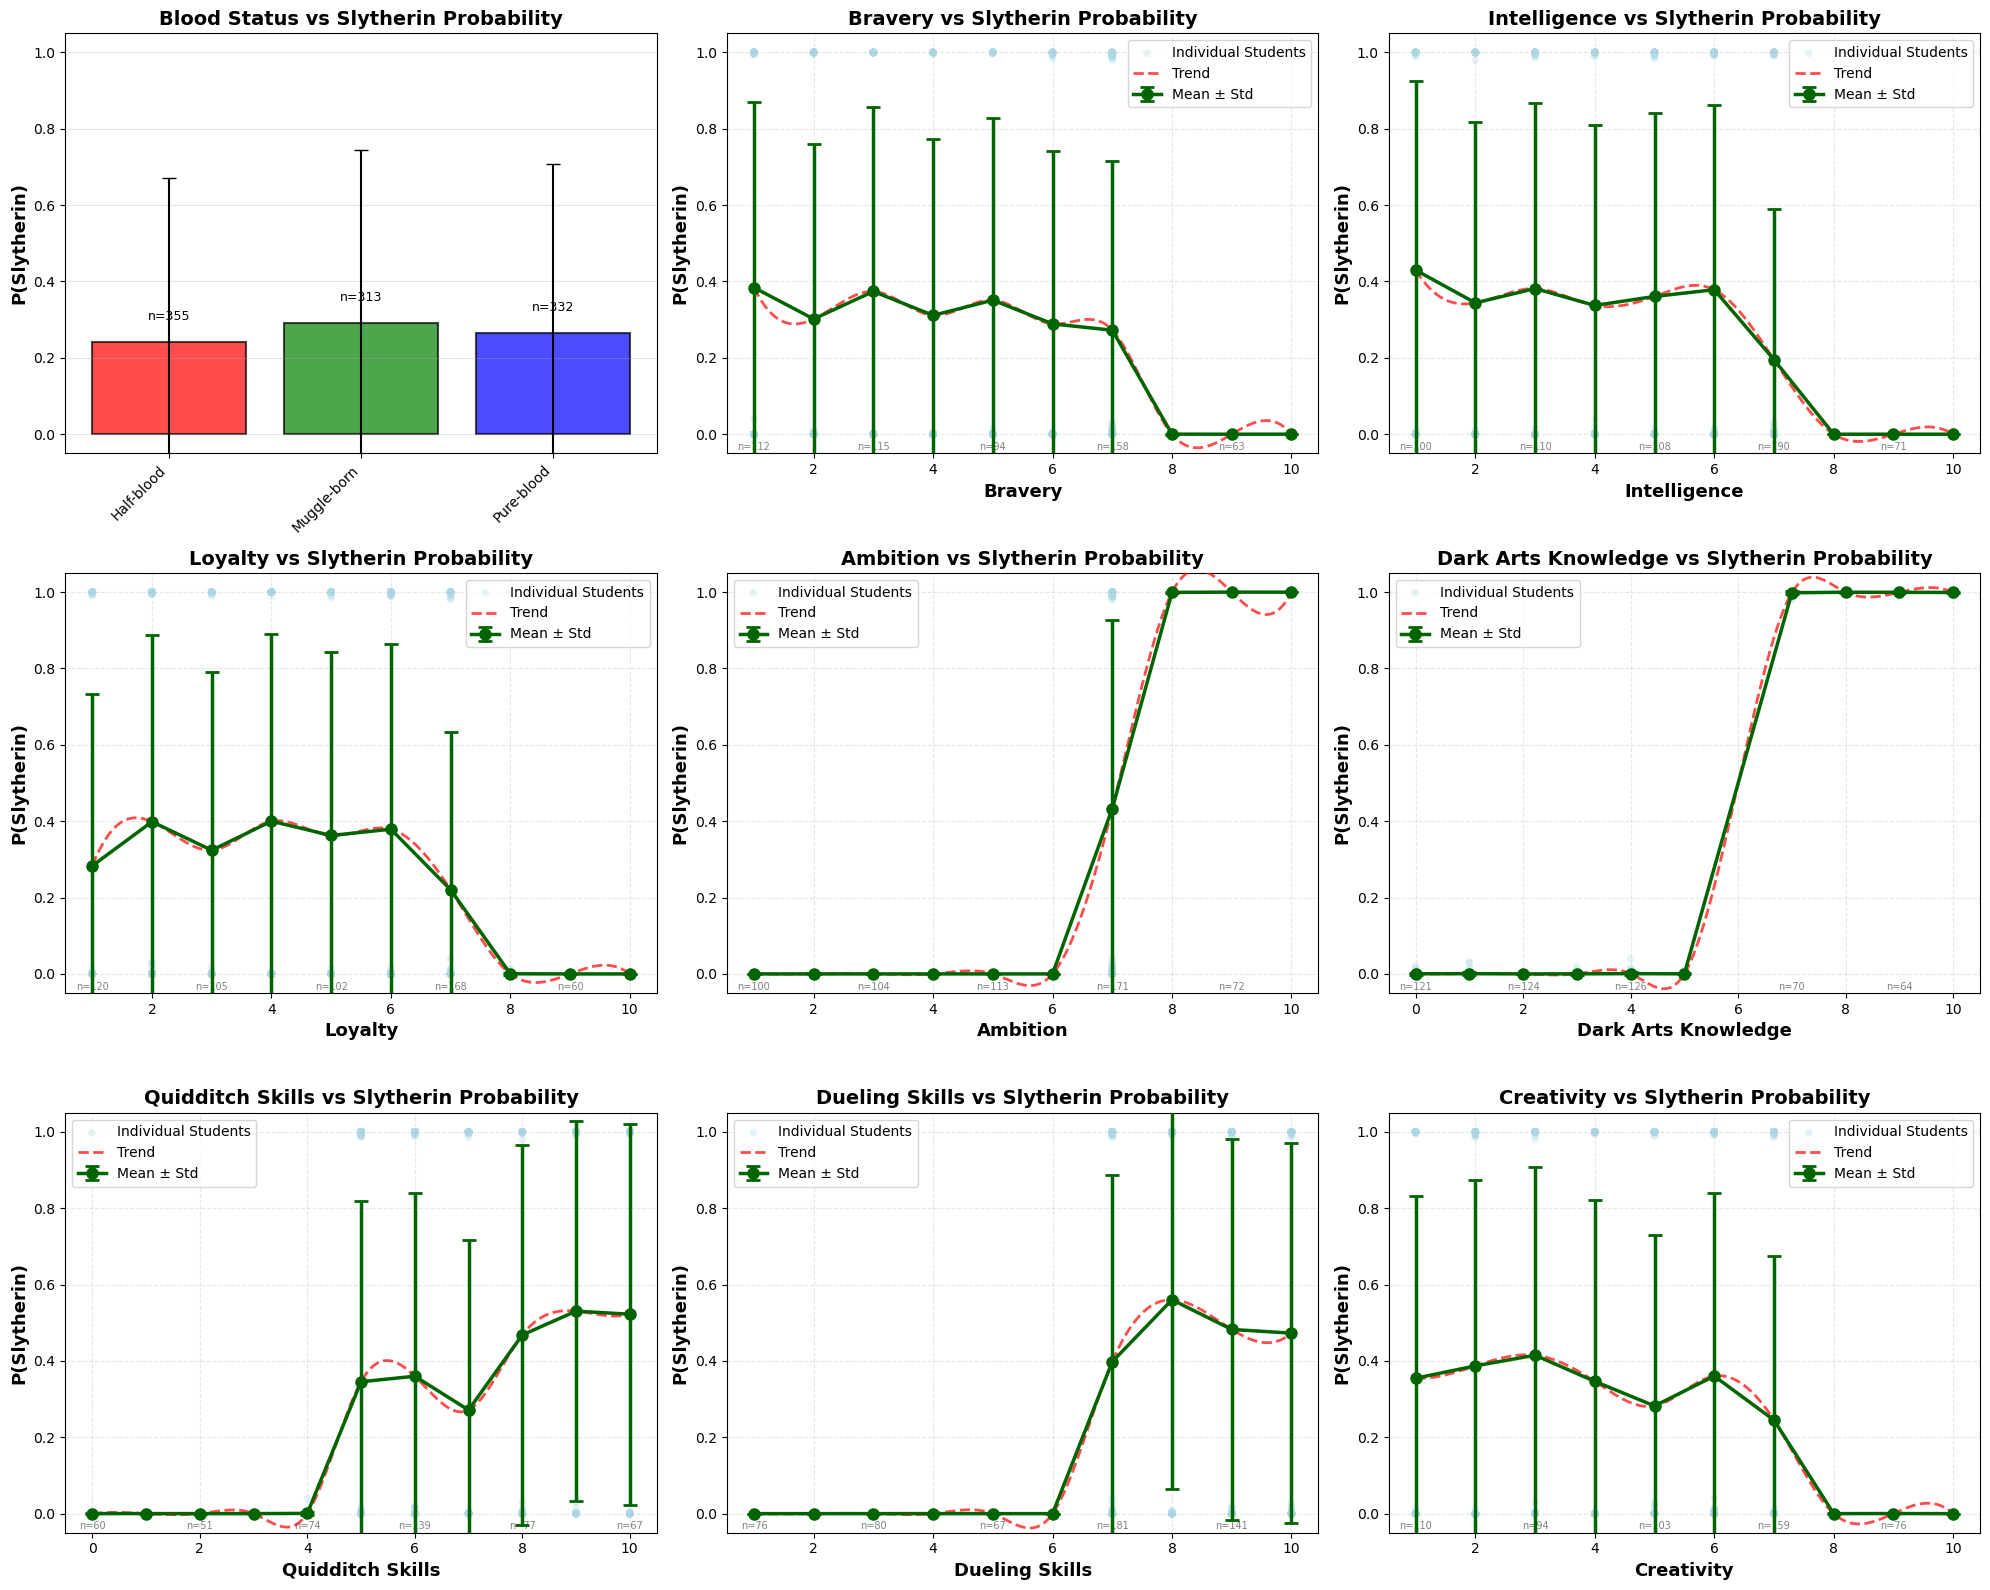


STATISTICAL SUMMARY

Blood Status:
----------------------------------------
                  mean       std  count
Blood Status                           
Half-blood    0.242310  0.428436    355
Muggle-born   0.290815  0.454292    313
Pure-blood    0.265151  0.441576    332


ValueError: could not convert string to float: 'Half-blood'

In [123]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.interpolate import make_interp_spline

# TRAIN A MODEL TO GET PROBABILITIES
print("\n" + "="*60)
print("SLYTHERIN PROBABILITY ANALYSIS")
print("="*60)

# Prepare features and target
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

feature_cols_prob = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                     'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                     'Dueling Skills', 'Creativity']

X_prob = df[feature_cols_prob].values
y_prob = df['House'].values

# Train a Random Forest to get probability estimates
print("\nTraining Random Forest for probability estimation...")
rf_prob = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=20)
rf_prob.fit(X_prob, y_prob)

# Get predicted probabilities for all houses
probs = rf_prob.predict_proba(X_prob)
house_names = rf_prob.classes_

# Get Slytherin probabilities
slytherin_idx = np.where(house_names == 'Slytherin')[0][0]
slytherin_probs = probs[:, slytherin_idx]

# Add to dataframe
df['Slytherin_Probability'] = slytherin_probs

print(f"Model trained. Classes: {house_names}")

# CREATE PLOTS FOR ALL FEATURES
print("\nCreating probability plots...")

features_to_plot = ['Blood Status', 'Bravery', 'Intelligence', 'Loyalty', 
                    'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                    'Dueling Skills', 'Creativity']
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Handle Blood Status separately (categorical)
    if feature == 'Blood Status':
        blood_status_probs = df.groupby('Blood Status')['Slytherin_Probability'].agg(['mean', 'std', 'count'])
        
        blood_types = blood_status_probs.index
        means = blood_status_probs['mean'].values
        stds = blood_status_probs['std'].values
        counts = blood_status_probs['count'].values
        
        x_pos = np.arange(len(blood_types))
        bars = ax.bar(x_pos, means, yerr=stds, capsize=5, 
                     color=['red', 'green', 'blue'], 
                     alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(blood_types, rotation=45, ha='right')
        ax.set_ylabel('P(Slytherin)', fontsize=13, fontweight='bold')
        ax.set_title(f'{feature} vs Slytherin Probability', 
                    fontsize=14, fontweight='bold')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add count labels
        for i, (bar, count) in enumerate(zip(bars, counts)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'n={count}', ha='center', va='bottom', fontsize=9)
        
        continue
    
    # Get feature values and corresponding Slytherin probabilities
    feature_values = df[feature].values
    probs_for_feature = df['Slytherin_Probability'].values
    
    # Calculate mean probability for each feature value
    unique_values = np.sort(df[feature].unique())
    mean_probs = []
    std_probs = []
    counts = []
    
    for val in unique_values:
        mask = feature_values == val
        mean_probs.append(probs_for_feature[mask].mean())
        std_probs.append(probs_for_feature[mask].std())
        counts.append(mask.sum())
    
    mean_probs = np.array(mean_probs)
    std_probs = np.array(std_probs)
    
    # Scatter plot: all individual data points
    ax.scatter(feature_values, probs_for_feature, 
              alpha=0.3, s=30, c='lightblue', edgecolors='none',
              label='Individual Students')
    
    # Line plot: mean probability with error bars
    ax.errorbar(unique_values, mean_probs, yerr=std_probs,
               fmt='o-', color='darkgreen', linewidth=2.5, 
               markersize=8, capsize=5, capthick=2,
               label='Mean ± Std', zorder=5)
    
    # Smooth trend line
    if len(unique_values) > 3:
        x_smooth = np.linspace(unique_values.min(), unique_values.max(), 300)
        spl = make_interp_spline(unique_values, mean_probs, k=min(3, len(unique_values)-1))
        y_smooth = spl(x_smooth)
        ax.plot(x_smooth, y_smooth, '--', color='red', linewidth=2, 
               alpha=0.7, label='Trend', zorder=4)
    
    # Formatting
    ax.set_xlabel(feature, fontsize=13, fontweight='bold')
    ax.set_ylabel('P(Slytherin)', fontsize=13, fontweight='bold')
    ax.set_title(f'{feature} vs Slytherin Probability', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([-0.05, 1.05])
    ax.legend(loc='best', fontsize=10)
    
    # Add sample size annotations at the bottom
    for i, (val, count) in enumerate(zip(unique_values, counts)):
        if i % 2 == 0:  # Show every other to avoid crowding
            ax.text(val, -0.02, f'n={count}', 
                   ha='center', va='top', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

# STATISTICAL SUMMARY
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

for feature in features_to_plot:
    print(f"\n{feature}:")
    print("-" * 40)
    
    # Group by feature value
    grouped = df.groupby(feature)['Slytherin_Probability'].agg(['mean', 'std', 'count'])
    print(grouped.to_string())
    
    # Correlation
    correlation = df[feature].corr(df['Slytherin_Probability'])
    print(f"\nCorrelation with Slytherin Probability: {correlation:.4f}")

# ADDITIONAL ANALYSIS: Combined effect
print("\n" + "="*60)
print("COMBINED EFFECT ANALYSIS")
print("="*60)

# Create bins for high/low values
df['High_Ambition'] = (df['Ambition'] >= 7).astype(int)
df['High_Dark_Arts'] = (df['Dark Arts Knowledge'] >= 7).astype(int)
df['High_Dueling'] = (df['Dueling Skills'] >= 7).astype(int)

# Analyze combinations
print("\nSlytherin Probability by Trait Combinations:")
print("-" * 60)

combinations = [
    (0, 0, 0, "Low All"),
    (1, 0, 0, "High Ambition Only"),
    (0, 1, 0, "High Dark Arts Only"),
    (0, 0, 1, "High Dueling Only"),
    (1, 1, 0, "High Ambition + Dark Arts"),
    (1, 0, 1, "High Ambition + Dueling"),
    (0, 1, 1, "High Dark Arts + Dueling"),
    (1, 1, 1, "High All Three"),
]

results = []
for amb, dark, duel, label in combinations:
    mask = (df['High_Ambition'] == amb) & \
           (df['High_Dark_Arts'] == dark) & \
           (df['High_Dueling'] == duel)
    
    if mask.sum() > 0:
        mean_prob = df.loc[mask, 'Slytherin_Probability'].mean()
        count = mask.sum()
        actual_slytherin = (df.loc[mask, 'House'] == 'Slytherin').sum()
        results.append((label, mean_prob, count, actual_slytherin))
        print(f"{label:30s}: P={mean_prob:.3f} (n={count:3d}, {actual_slytherin:3d} actual Slytherins)")

# Visualize combined effects
fig, ax = plt.subplots(figsize=(12, 6))

labels = [r[0] for r in results]
probs = [r[1] for r in results]
counts = [r[2] for r in results]

bars = ax.bar(range(len(labels)), probs, color='#1A472A', edgecolor='black', linewidth=1.5)

# Color gradient based on probability
for i, (bar, prob) in enumerate(zip(bars, probs)):
    bar.set_color(plt.cm.RdYlGn_r(prob))

ax.set_ylabel('Mean P(Slytherin)', fontsize=13, fontweight='bold')
ax.set_xlabel('Trait Combination', fontsize=13, fontweight='bold')
ax.set_title('Slytherin Probability by Trait Combinations', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, prob, count) in enumerate(zip(bars, probs, counts)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{prob:.2f}\n(n={count})', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print("1. Check the individual feature plots to see which trait")
print("   most strongly predicts Slytherin membership")
print("2. The combined effects show how multiple 'Slytherin traits'")
print("   work together to increase probability")
print("3. Error bars show variability - wide bars mean inconsistent prediction")


DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Base Blood Status Weight: 1.0
Maximum Blood Status Weight: 500000001.0

Blood Status Weight Statistics:
  Min:    1.00
  Mean:   123638889.89
  Median: 50000001.00
  Max:    500000001.00

Weight Distribution by Ambition & Dark Arts Levels:
------------------------------------------------------------
  High   Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)
  High   Ambition + Medium Dark Arts: Avg Weight = 336678005.54 (n=294)
  High   Ambition + Low    Dark Arts: Avg Weight = 282274402.47 (n=362)
  Medium Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)
  Medium Ambition + Medium Dark Arts: Avg Weight = 275112234.45 (n=396)
  Medium Ambition + Low    Dark Arts: Avg Weight = 178159204.98 (n=670)
  Low    Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)

Applying dynamic weighted K-means with 4 clusters...

Dynamic Weighted Clustering Metrics:
  Silhouette Score: 0.3051
  Adjusted 

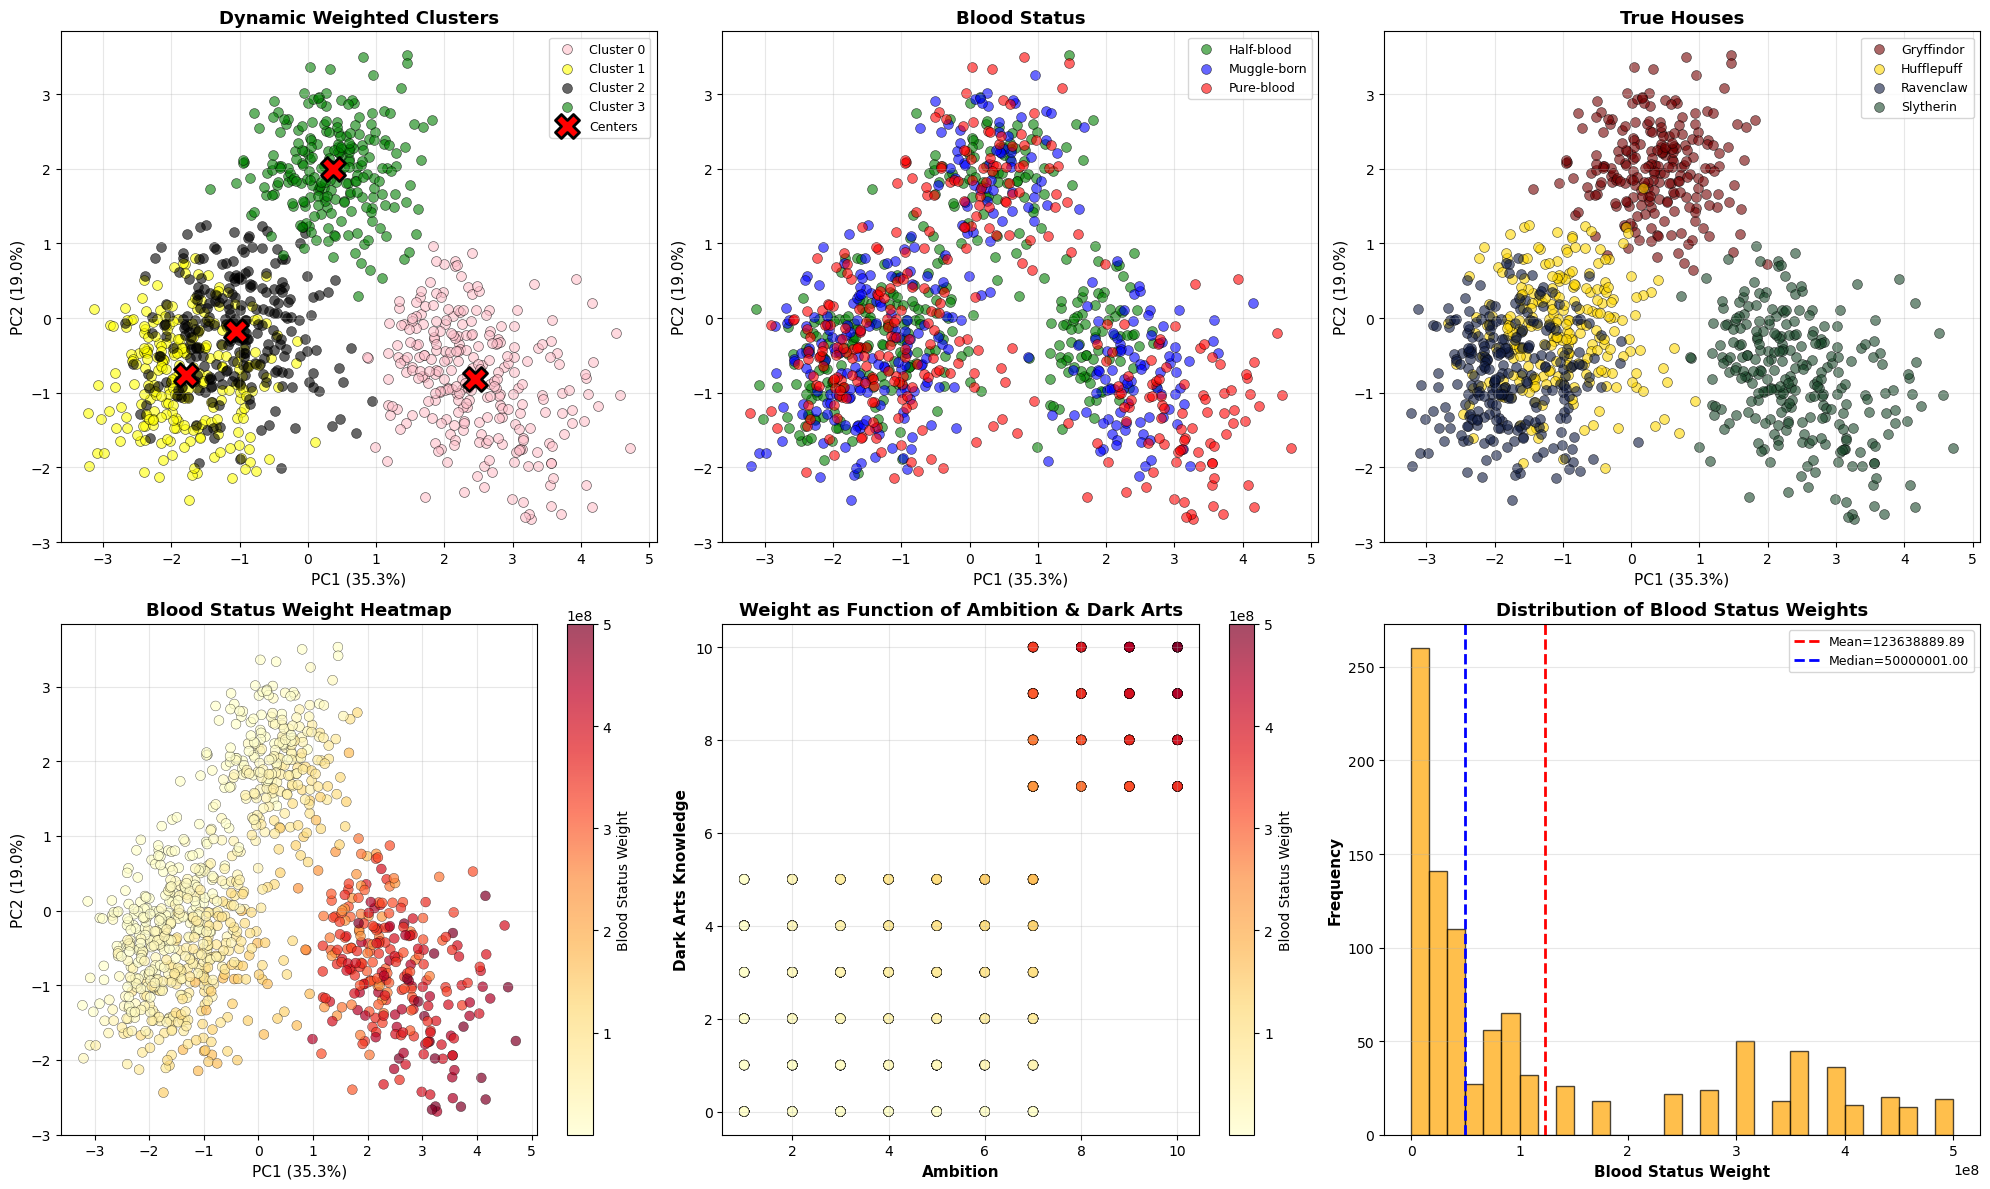


COMPARISON: STATIC vs DYNAMIC WEIGHTING

Static Weighted Clustering (Blood Status Weight: 500x):
  ARI vs Houses: -0.0005
  Silhouette Score: 1.0000

Dynamic Weighted Clustering (Weight: 1-500000001.0):
  ARI vs Houses: 0.9869
  Silhouette Score: 0.3051

------------------------------------------------------------
INTERPRETATION:
------------------------------------------------------------
Dynamic weighting means:
  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status matters MORE
  • Students with LOW Ambition + LOW Dark Arts → Blood Status matters LESS
  • This simulates 'blood purity matters more to ambitious dark wizards'

Check the 'Weight as Function' plot to see how weights vary!


In [140]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)

# Prepare features
cluster_features_dynamic = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                            'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                            'Dueling Skills', 'Creativity']

X_dynamic = df[cluster_features_dynamic].values

# Extract all features
blood_status = X_dynamic[:, 0]
bravery = X_dynamic[:, 1]
intelligence = X_dynamic[:, 2]
loyalty = X_dynamic[:, 3]
ambition = X_dynamic[:, 4]
dark_arts = X_dynamic[:, 5]
quidditch = X_dynamic[:, 6]
dueling = X_dynamic[:, 7]
creativity = X_dynamic[:, 8]

# Normalize ALL attributes to [0, 1] range
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bravery_norm = normalize(bravery)
intelligence_norm = normalize(intelligence)
loyalty_norm = normalize(loyalty)
ambition_norm = normalize(ambition)
dark_arts_norm = normalize(dark_arts)
quidditch_norm = normalize(quidditch)
dueling_norm = normalize(dueling)
creativity_norm = normalize(creativity)

# Create dynamic weight for Blood Status based on Ambition and Dark Arts
# Weight formula: base_weight + scaling_factor * (ambition_norm * dark_arts_norm)
base_weight = 1.0  # Minimum weight
scaling_factor = 500000000.0  # Maximum additional weight
power = 2.5  # Exponent to amplify high values (makes the effect non-linear)


# Calculate per-instance blood status weight
# High ambition AND high dark arts → high blood status weight
#blood_status_weights = base_weight + scaling_factor * (ambition_norm * dark_arts_norm / ( 1+ bravery_norm * intelligence_norm * loyalty_norm * quidditch_norm * dueling_norm * creativity_norm))
blood_status_weights = base_weight + scaling_factor * (ambition_norm * dark_arts_norm)

print(f"\nBase Blood Status Weight: {base_weight}")
print(f"Maximum Blood Status Weight: {base_weight + scaling_factor}")
print(f"\nBlood Status Weight Statistics:")
print(f"  Min:    {blood_status_weights.min():.2f}")
print(f"  Mean:   {blood_status_weights.mean():.2f}")
print(f"  Median: {np.median(blood_status_weights):.2f}")
print(f"  Max:    {blood_status_weights.max():.2f}")

# Show distribution of weights
print(f"\nWeight Distribution by Ambition & Dark Arts Levels:")
print("-" * 60)
for amb_threshold, amb_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
    for dark_threshold, dark_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
        mask = (ambition >= amb_threshold) & (dark_arts >= dark_threshold)
        if mask.sum() > 0:
            avg_weight = blood_status_weights[mask].mean()
            count = mask.sum()
            print(f"  {amb_label:6s} Ambition + {dark_label:6s} Dark Arts: "
                  f"Avg Weight = {avg_weight:5.2f} (n={count:3d})")
        if amb_threshold == 0 or dark_threshold == 0:
            break
    if amb_threshold == 0:
        break

# Create weighted feature matrix
X_dynamic_weighted = X_dynamic.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_dynamic_weighted[:, 0] = X_dynamic[:, 0] * blood_status_weights

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means
print("\nApplying dynamic weighted K-means with 4 clusters...")
kmeans_dynamic = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)

# Calculate metrics
silhouette_dynamic = silhouette_score(X_dynamic_scaled, clusters_dynamic)
ari_dynamic = adjusted_rand_score(df['House'], clusters_dynamic)

print(f"\nDynamic Weighted Clustering Metrics:")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")
print(f"  Adjusted Rand Index (vs Houses): {ari_dynamic:.4f}")

# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights

# Show cluster distribution
print("\n" + "-"*60)
print("Dynamic Cluster Distribution:")
print("-"*60)
unique_clusters_d, cluster_counts_d = np.unique(clusters_dynamic, return_counts=True)
for cluster, count in zip(unique_clusters_d, cluster_counts_d):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Dynamic Clusters vs Blood Status
print("\n" + "-"*60)
print("Dynamic Cluster vs Blood Status:")
print("-"*60)
crosstab_blood_d = pd.crosstab(df['Dynamic_Cluster'], df['Blood Status'], margins=True)
print(crosstab_blood_d)

# Cross-tabulation: Dynamic Clusters vs Houses
print("\n" + "-"*60)
print("Dynamic Cluster vs House:")
print("-"*60)
crosstab_house_d = pd.crosstab(df['Dynamic_Cluster'], df['House'], margins=True)
print(crosstab_house_d)

# Analyze clusters with high blood status weight
print("\n" + "-"*60)
print("Average Blood Status Weight by Cluster:")
print("-"*60)
for cluster in sorted(df['Dynamic_Cluster'].unique()):
    cluster_mask = df['Dynamic_Cluster'] == cluster
    avg_weight = df.loc[cluster_mask, 'Blood_Status_Weight'].mean()
    avg_ambition = df.loc[cluster_mask, 'Ambition'].mean()
    avg_dark_arts = df.loc[cluster_mask, 'Dark Arts Knowledge'].mean()
    print(f"  Cluster {cluster}: Weight={avg_weight:5.2f}, "
          f"Ambition={avg_ambition:.2f}, Dark Arts={avg_dark_arts:.2f}")

# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['pink', 'yellow', 'black', 'green']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)

ax1.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('Dynamic Weighted Clusters', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax3.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Colored by Blood Status Weight (heatmap style)
ax4 = plt.subplot(2, 3, 4)
scatter = ax4.scatter(X_pca_dynamic[:, 0], X_pca_dynamic[:, 1],
                     c=blood_status_weights,
                     cmap='YlOrRd',
                     s=50,
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Blood Status Weight', fontsize=10)
ax4.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax4.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax4.set_title('Blood Status Weight Heatmap', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Ambition vs Dark Arts colored by Blood Status Weight
ax5 = plt.subplot(2, 3, 5)
scatter5 = ax5.scatter(ambition, dark_arts,
                      c=blood_status_weights,
                      cmap='YlOrRd',
                      s=50,
                      alpha=0.7,
                      edgecolors='black',
                      linewidth=0.3)
cbar5 = plt.colorbar(scatter5, ax=ax5)
cbar5.set_label('Blood Status Weight', fontsize=10)
ax5.set_xlabel('Ambition', fontsize=11, fontweight='bold')
ax5.set_ylabel('Dark Arts Knowledge', fontsize=11, fontweight='bold')
ax5.set_title('Weight as Function of Ambition & Dark Arts', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Weight distribution histogram
ax6 = plt.subplot(2, 3, 6)
ax6.hist(blood_status_weights, bins=30, color='orange', edgecolor='black', alpha=0.7)
ax6.axvline(blood_status_weights.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={blood_status_weights.mean():.2f}')
ax6.axvline(np.median(blood_status_weights), color='blue', linestyle='--', linewidth=2, label=f'Median={np.median(blood_status_weights):.2f}')
ax6.set_xlabel('Blood Status Weight', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6.set_title('Distribution of Blood Status Weights', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# COMPARISON
print("\n" + "="*60)
print("COMPARISON: STATIC vs DYNAMIC WEIGHTING")
print("="*60)

if 'Weighted_Cluster' in df.columns:
    print(f"\nStatic Weighted Clustering (Blood Status Weight: {blood_status_weight}x):")
    print(f"  ARI vs Houses: {ari_weighted:.4f}")
    print(f"  Silhouette Score: {silhouette_weighted:.4f}")

print(f"\nDynamic Weighted Clustering (Weight: 1-{base_weight + scaling_factor}):")
print(f"  ARI vs Houses: {ari_dynamic:.4f}")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")

print("\n" + "-"*60)
print("INTERPRETATION:")
print("-"*60)
print("Dynamic weighting means:")
print("  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status matters MORE")
print("  • Students with LOW Ambition + LOW Dark Arts → Blood Status matters LESS")
print("  • This simulates 'blood purity matters more to ambitious dark wizards'")
print("\nCheck the 'Weight as Function' plot to see how weights vary!")


DYNAMIC AGGLOMERATIVE CLUSTERING (based on Ambition & Dark Arts)

Base Blood Status Weight: 1.0
Maximum Blood Status Weight: 51.0

Blood Status Weight Statistics:
  Min:    1.00
  Mean:   13.36
  Median: 6.00
  Max:    51.00

------------------------------------------------------------
Testing Different Linkage Methods:
------------------------------------------------------------
  ward      : Silhouette=0.3019, ARI=0.9738
  complete  : Silhouette=0.3021, ARI=0.9812
  average   : Silhouette=0.3039, ARI=0.9841
  single    : Silhouette=-0.0572, ARI=-0.0002

Best linkage method: average (Silhouette=0.3039)

Final Agglomerative Clustering Metrics (using average):
  Silhouette Score: 0.3039
  Adjusted Rand Index (vs Houses): 0.9841

------------------------------------------------------------
Agglomerative Cluster Distribution:
------------------------------------------------------------
  Cluster 0: 266 students (26.6%)
  Cluster 1: 248 students (24.8%)
  Cluster 2: 226 students (22.6%)
 

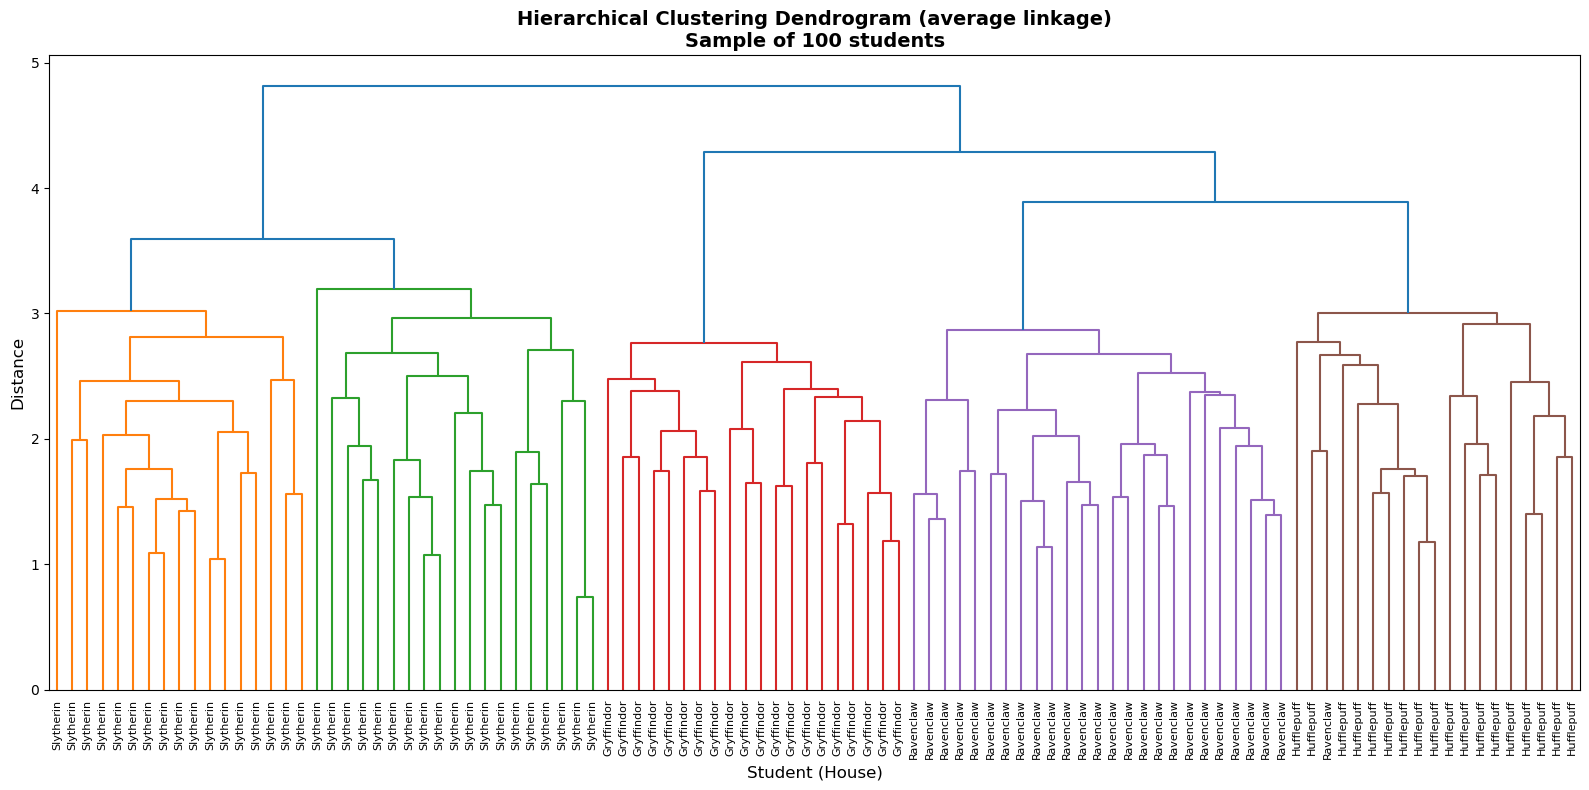

Dendrogram shown for sample of 100 students

VISUALIZING AGGLOMERATIVE CLUSTERS


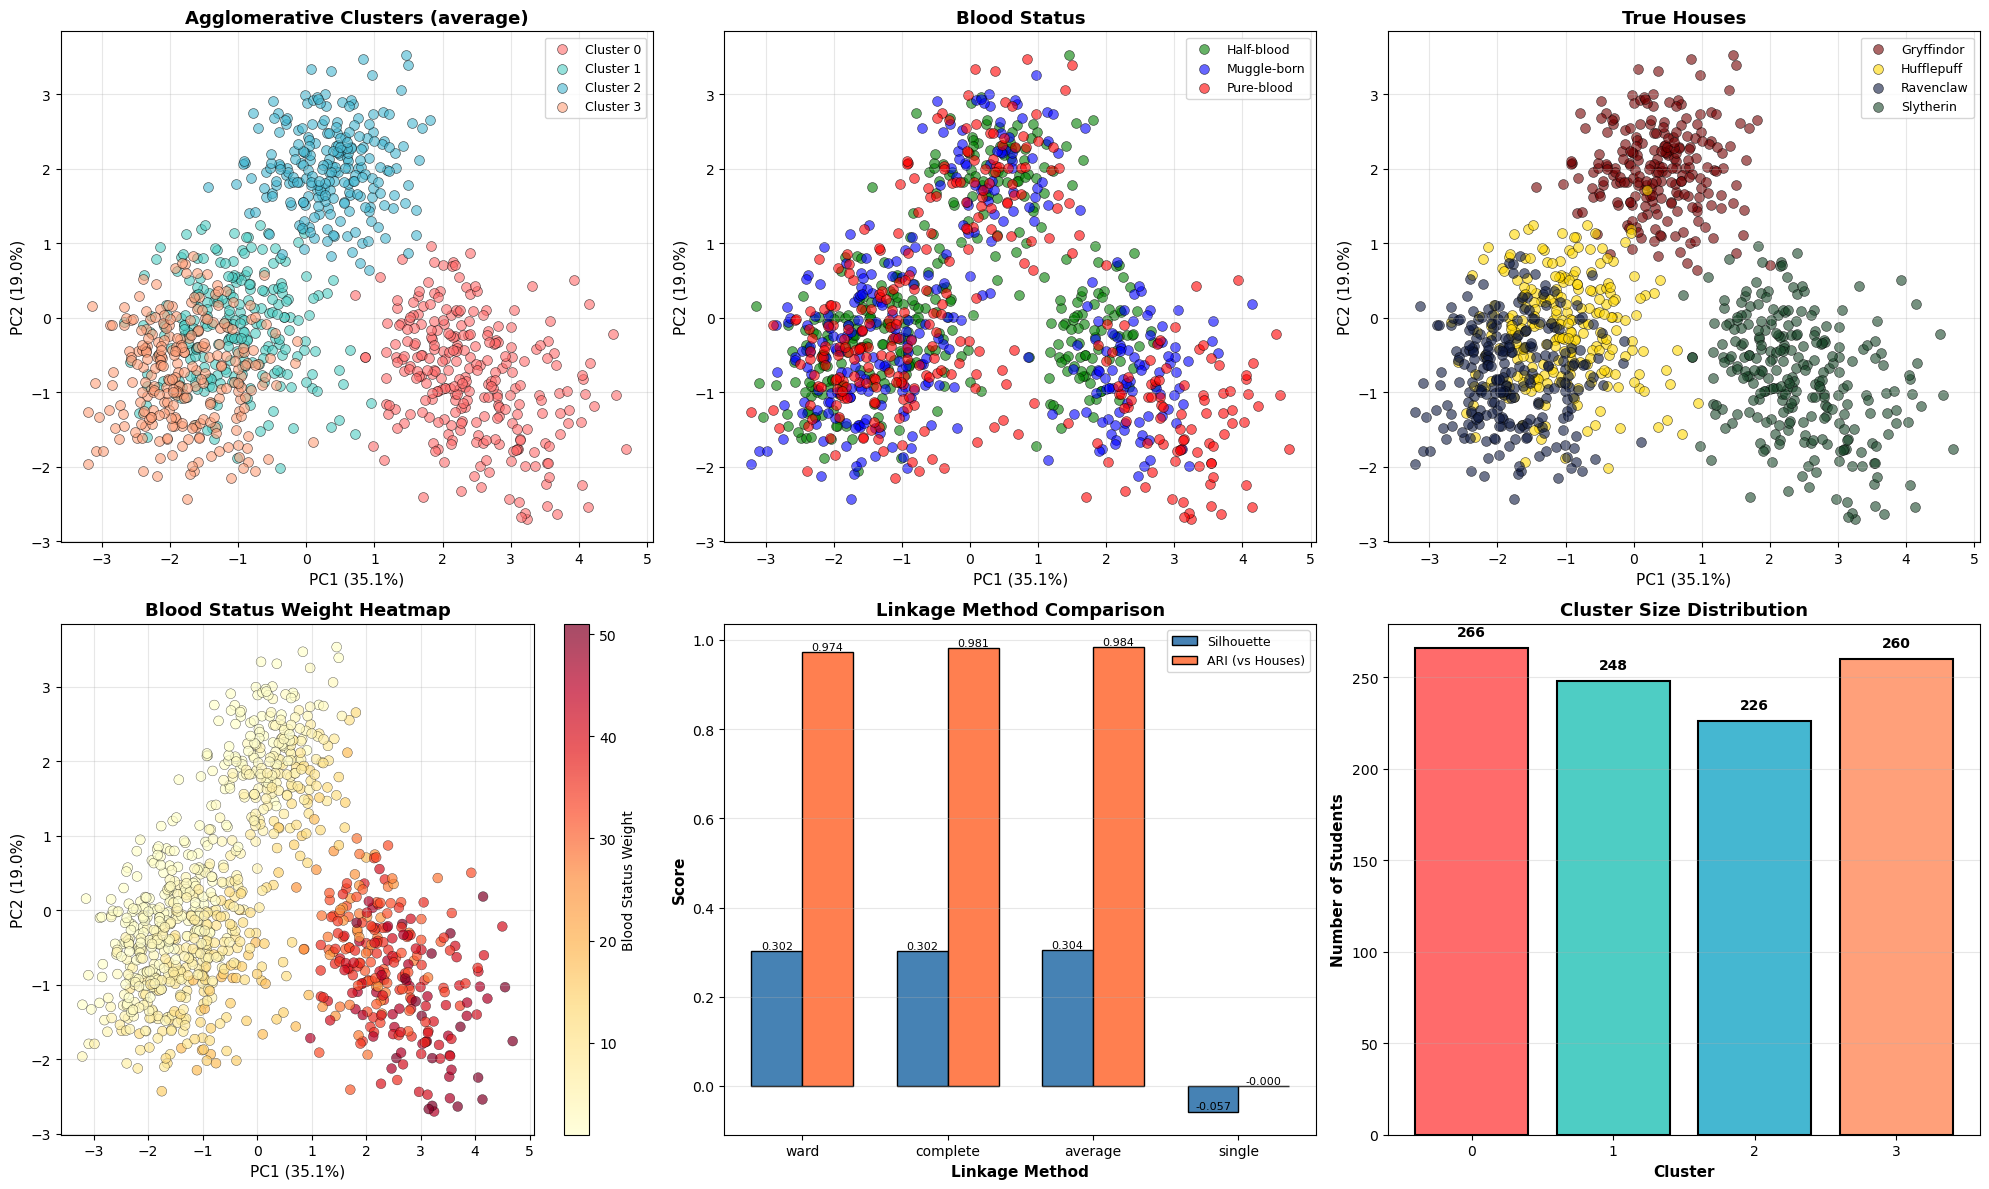


COMPARISON: K-MEANS vs AGGLOMERATIVE CLUSTERING

K-Means (Dynamic Weighted):
  ARI vs Houses: 0.9869
  Silhouette Score: 0.3041

Agglomerative (average linkage, Dynamic Weighted):
  ARI vs Houses: 0.9841
  Silhouette Score: 0.3039

------------------------------------------------------------
KEY DIFFERENCES:
------------------------------------------------------------
K-Means:
  • Assumes spherical clusters
  • Uses distance to cluster centers
  • Sensitive to initialization

Agglomerative:
  • Can find irregular shaped clusters
  • Builds hierarchy bottom-up
  • Deterministic (no randomness)
  • Different linkage methods affect results


In [126]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import numpy as np

# DYNAMIC WEIGHTED AGGLOMERATIVE CLUSTERING
print("\n" + "="*60)
print("DYNAMIC AGGLOMERATIVE CLUSTERING (based on Ambition & Dark Arts)")
print("="*60)

# Prepare features
cluster_features_agg = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                        'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                        'Dueling Skills', 'Creativity']

X_agg = df[cluster_features_agg].values

# Extract Ambition and Dark Arts Knowledge (indices 4 and 5)
ambition = X_agg[:, 4]
dark_arts = X_agg[:, 5]

# Normalize Ambition and Dark Arts to [0, 1] range
ambition_norm = (ambition - ambition.min()) / (ambition.max() - ambition.min())
dark_arts_norm = (dark_arts - dark_arts.min()) / (dark_arts.max() - dark_arts.min())

# Create dynamic weight for Blood Status based on Ambition and Dark Arts
base_weight = 1.0
scaling_factor = 50.0

# Calculate per-instance blood status weight
blood_status_weights_agg = base_weight + scaling_factor * (ambition_norm * dark_arts_norm)

print(f"\nBase Blood Status Weight: {base_weight}")
print(f"Maximum Blood Status Weight: {base_weight + scaling_factor}")
print(f"\nBlood Status Weight Statistics:")
print(f"  Min:    {blood_status_weights_agg.min():.2f}")
print(f"  Mean:   {blood_status_weights_agg.mean():.2f}")
print(f"  Median: {np.median(blood_status_weights_agg):.2f}")
print(f"  Max:    {blood_status_weights_agg.max():.2f}")

# Create weighted feature matrix
X_agg_weighted = X_agg.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_agg_weighted[:, 0] = X_agg[:, 0] * blood_status_weights_agg

# Standardize the weighted features
scaler_agg = StandardScaler()
X_agg_scaled = scaler_agg.fit_transform(X_agg_weighted)

# Try different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
best_silhouette = -1
best_method = None
results = {}

print("\n" + "-"*60)
print("Testing Different Linkage Methods:")
print("-"*60)

for method in linkage_methods:
    agg_clustering = AgglomerativeClustering(n_clusters=4, linkage=method)
    clusters_temp = agg_clustering.fit_predict(X_agg_scaled)
    
    silhouette_temp = silhouette_score(X_agg_scaled, clusters_temp)
    ari_temp = adjusted_rand_score(df['House'], clusters_temp)
    
    results[method] = {
        'silhouette': silhouette_temp,
        'ari': ari_temp,
        'clusters': clusters_temp
    }
    
    print(f"  {method:10s}: Silhouette={silhouette_temp:.4f}, ARI={ari_temp:.4f}")
    
    if silhouette_temp > best_silhouette:
        best_silhouette = silhouette_temp
        best_method = method

print(f"\nBest linkage method: {best_method} (Silhouette={best_silhouette:.4f})")

# Use the best method for final clustering
agg_clustering_final = AgglomerativeClustering(n_clusters=4, linkage=best_method)
clusters_agg = agg_clustering_final.fit_predict(X_agg_scaled)

silhouette_agg = results[best_method]['silhouette']
ari_agg = results[best_method]['ari']

print(f"\nFinal Agglomerative Clustering Metrics (using {best_method}):")
print(f"  Silhouette Score: {silhouette_agg:.4f}")
print(f"  Adjusted Rand Index (vs Houses): {ari_agg:.4f}")

# Add agglomerative cluster labels to dataframe
df['Agglomerative_Cluster'] = clusters_agg
df['Blood_Status_Weight_Agg'] = blood_status_weights_agg

# Show cluster distribution
print("\n" + "-"*60)
print("Agglomerative Cluster Distribution:")
print("-"*60)
unique_clusters_agg, cluster_counts_agg = np.unique(clusters_agg, return_counts=True)
for cluster, count in zip(unique_clusters_agg, cluster_counts_agg):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Agglomerative Clusters vs Blood Status
print("\n" + "-"*60)
print("Agglomerative Cluster vs Blood Status:")
print("-"*60)
crosstab_blood_agg = pd.crosstab(df['Agglomerative_Cluster'], df['Blood Status'], margins=True)
print(crosstab_blood_agg)

# Cross-tabulation: Agglomerative Clusters vs Houses
print("\n" + "-"*60)
print("Agglomerative Cluster vs House:")
print("-"*60)
crosstab_house_agg = pd.crosstab(df['Agglomerative_Cluster'], df['House'], margins=True)
print(crosstab_house_agg)

# Cluster-to-House mapping
print("\n" + "-"*60)
print("Cluster-to-House Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Agglomerative_Cluster'].unique()):
    house_counts = df[df['Agglomerative_Cluster'] == cluster]['House'].value_counts()
    majority_house = house_counts.index[0]
    majority_count = house_counts.iloc[0]
    total = len(df[df['Agglomerative_Cluster'] == cluster])
    print(f"  Cluster {cluster} → {majority_house:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# Analyze clusters with high blood status weight
print("\n" + "-"*60)
print("Average Blood Status Weight by Cluster:")
print("-"*60)
for cluster in sorted(df['Agglomerative_Cluster'].unique()):
    cluster_mask = df['Agglomerative_Cluster'] == cluster
    avg_weight = df.loc[cluster_mask, 'Blood_Status_Weight_Agg'].mean()
    avg_ambition = df.loc[cluster_mask, 'Ambition'].mean()
    avg_dark_arts = df.loc[cluster_mask, 'Dark Arts Knowledge'].mean()
    print(f"  Cluster {cluster}: Weight={avg_weight:5.2f}, "
          f"Ambition={avg_ambition:.2f}, Dark Arts={avg_dark_arts:.2f}")

# DENDROGRAM
print("\n" + "="*60)
print("CREATING DENDROGRAM")
print("="*60)

# For visualization, use a sample if dataset is large
sample_size = min(100, len(X_agg_scaled))
sample_indices = np.random.choice(len(X_agg_scaled), sample_size, replace=False)
X_sample = X_agg_scaled[sample_indices]
sample_labels = df.iloc[sample_indices]['House'].values

# Compute linkage for dendrogram
Z = linkage(X_sample, method=best_method)

# Create dendrogram
plt.figure(figsize=(16, 8))
dendrogram(Z, labels=sample_labels, leaf_font_size=8)
plt.title(f'Hierarchical Clustering Dendrogram ({best_method} linkage)\n'
          f'Sample of {sample_size} students', fontsize=14, fontweight='bold')
plt.xlabel('Student (House)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Dendrogram shown for sample of {sample_size} students")

# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING AGGLOMERATIVE CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_agg = PCA(n_components=2, random_state=42)
X_pca_agg = pca_agg.fit_transform(X_agg_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Agglomerative Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_agg == cluster
    ax1.scatter(X_pca_agg[mask, 0], X_pca_agg[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax1.set_xlabel(f'PC1 ({pca_agg.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_agg.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title(f'Agglomerative Clusters ({best_method})', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_agg[mask, 0], X_pca_agg[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'PC1 ({pca_agg.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca_agg.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_agg[mask, 0], X_pca_agg[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'PC1 ({pca_agg.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax3.set_ylabel(f'PC2 ({pca_agg.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Colored by Blood Status Weight
ax4 = plt.subplot(2, 3, 4)
scatter = ax4.scatter(X_pca_agg[:, 0], X_pca_agg[:, 1],
                     c=blood_status_weights_agg,
                     cmap='YlOrRd',
                     s=50,
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Blood Status Weight', fontsize=10)
ax4.set_xlabel(f'PC1 ({pca_agg.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax4.set_ylabel(f'PC2 ({pca_agg.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax4.set_title('Blood Status Weight Heatmap', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Comparison of all linkage methods
ax5 = plt.subplot(2, 3, 5)
methods = list(results.keys())
silhouettes = [results[m]['silhouette'] for m in methods]
aris = [results[m]['ari'] for m in methods]

x_pos = np.arange(len(methods))
width = 0.35

bars1 = ax5.bar(x_pos - width/2, silhouettes, width, label='Silhouette', 
                color='steelblue', edgecolor='black')
bars2 = ax5.bar(x_pos + width/2, aris, width, label='ARI (vs Houses)', 
                color='coral', edgecolor='black')

ax5.set_xlabel('Linkage Method', fontsize=11, fontweight='bold')
ax5.set_ylabel('Score', fontsize=11, fontweight='bold')
ax5.set_title('Linkage Method Comparison', fontsize=13, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(methods)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 6: Cluster size comparison
ax6 = plt.subplot(2, 3, 6)
cluster_nums = sorted(df['Agglomerative_Cluster'].unique())
cluster_sizes = [len(df[df['Agglomerative_Cluster'] == c]) for c in cluster_nums]

bars = ax6.bar(cluster_nums, cluster_sizes, color=cluster_colors, edgecolor='black', linewidth=1.5)
ax6.set_xlabel('Cluster', fontsize=11, fontweight='bold')
ax6.set_ylabel('Number of Students', fontsize=11, fontweight='bold')
ax6.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
ax6.set_xticks(cluster_nums)
ax6.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, size in zip(bars, cluster_sizes):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{size}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# COMPARISON WITH K-MEANS
print("\n" + "="*60)
print("COMPARISON: K-MEANS vs AGGLOMERATIVE CLUSTERING")
print("="*60)

if 'Dynamic_Cluster' in df.columns:
    print(f"\nK-Means (Dynamic Weighted):")
    print(f"  ARI vs Houses: {ari_dynamic:.4f}")
    print(f"  Silhouette Score: {silhouette_dynamic:.4f}")

print(f"\nAgglomerative ({best_method} linkage, Dynamic Weighted):")
print(f"  ARI vs Houses: {ari_agg:.4f}")
print(f"  Silhouette Score: {silhouette_agg:.4f}")

print("\n" + "-"*60)
print("KEY DIFFERENCES:")
print("-"*60)
print("K-Means:")
print("  • Assumes spherical clusters")
print("  • Uses distance to cluster centers")
print("  • Sensitive to initialization")
print("\nAgglomerative:")
print("  • Can find irregular shaped clusters")
print("  • Builds hierarchy bottom-up")
print("  • Deterministic (no randomness)")
print("  • Different linkage methods affect results")


DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Base Blood Status Weight: 1.0
Maximum Blood Status Weight: 101.0
Power Factor: 2.5 (higher = more dramatic effect for high values)

Blood Status Weight Statistics:
  Min:    1.00
  Mean:   13.74
  Median: 1.32
  Max:    101.00

Weight Distribution by Ambition & Dark Arts Levels:
------------------------------------------------------------
  High   Ambition + High   Dark Arts: Avg Weight = 47.38 (n=265)
  High   Ambition + Medium Dark Arts: Avg Weight = 43.33 (n=294)
  High   Ambition + Low    Dark Arts: Avg Weight = 35.49 (n=362)
  Medium Ambition + High   Dark Arts: Avg Weight = 47.38 (n=265)
  Medium Ambition + Medium Dark Arts: Avg Weight = 32.91 (n=396)
  Medium Ambition + Low    Dark Arts: Avg Weight = 20.00 (n=670)
  Low    Ambition + High   Dark Arts: Avg Weight = 47.38 (n=265)

Applying dynamic weighted K-means with 4 clusters...

Dynamic Weighted Clustering Metrics:
  Silhouette Score: 0.3041
  Adjusted Rand Inde

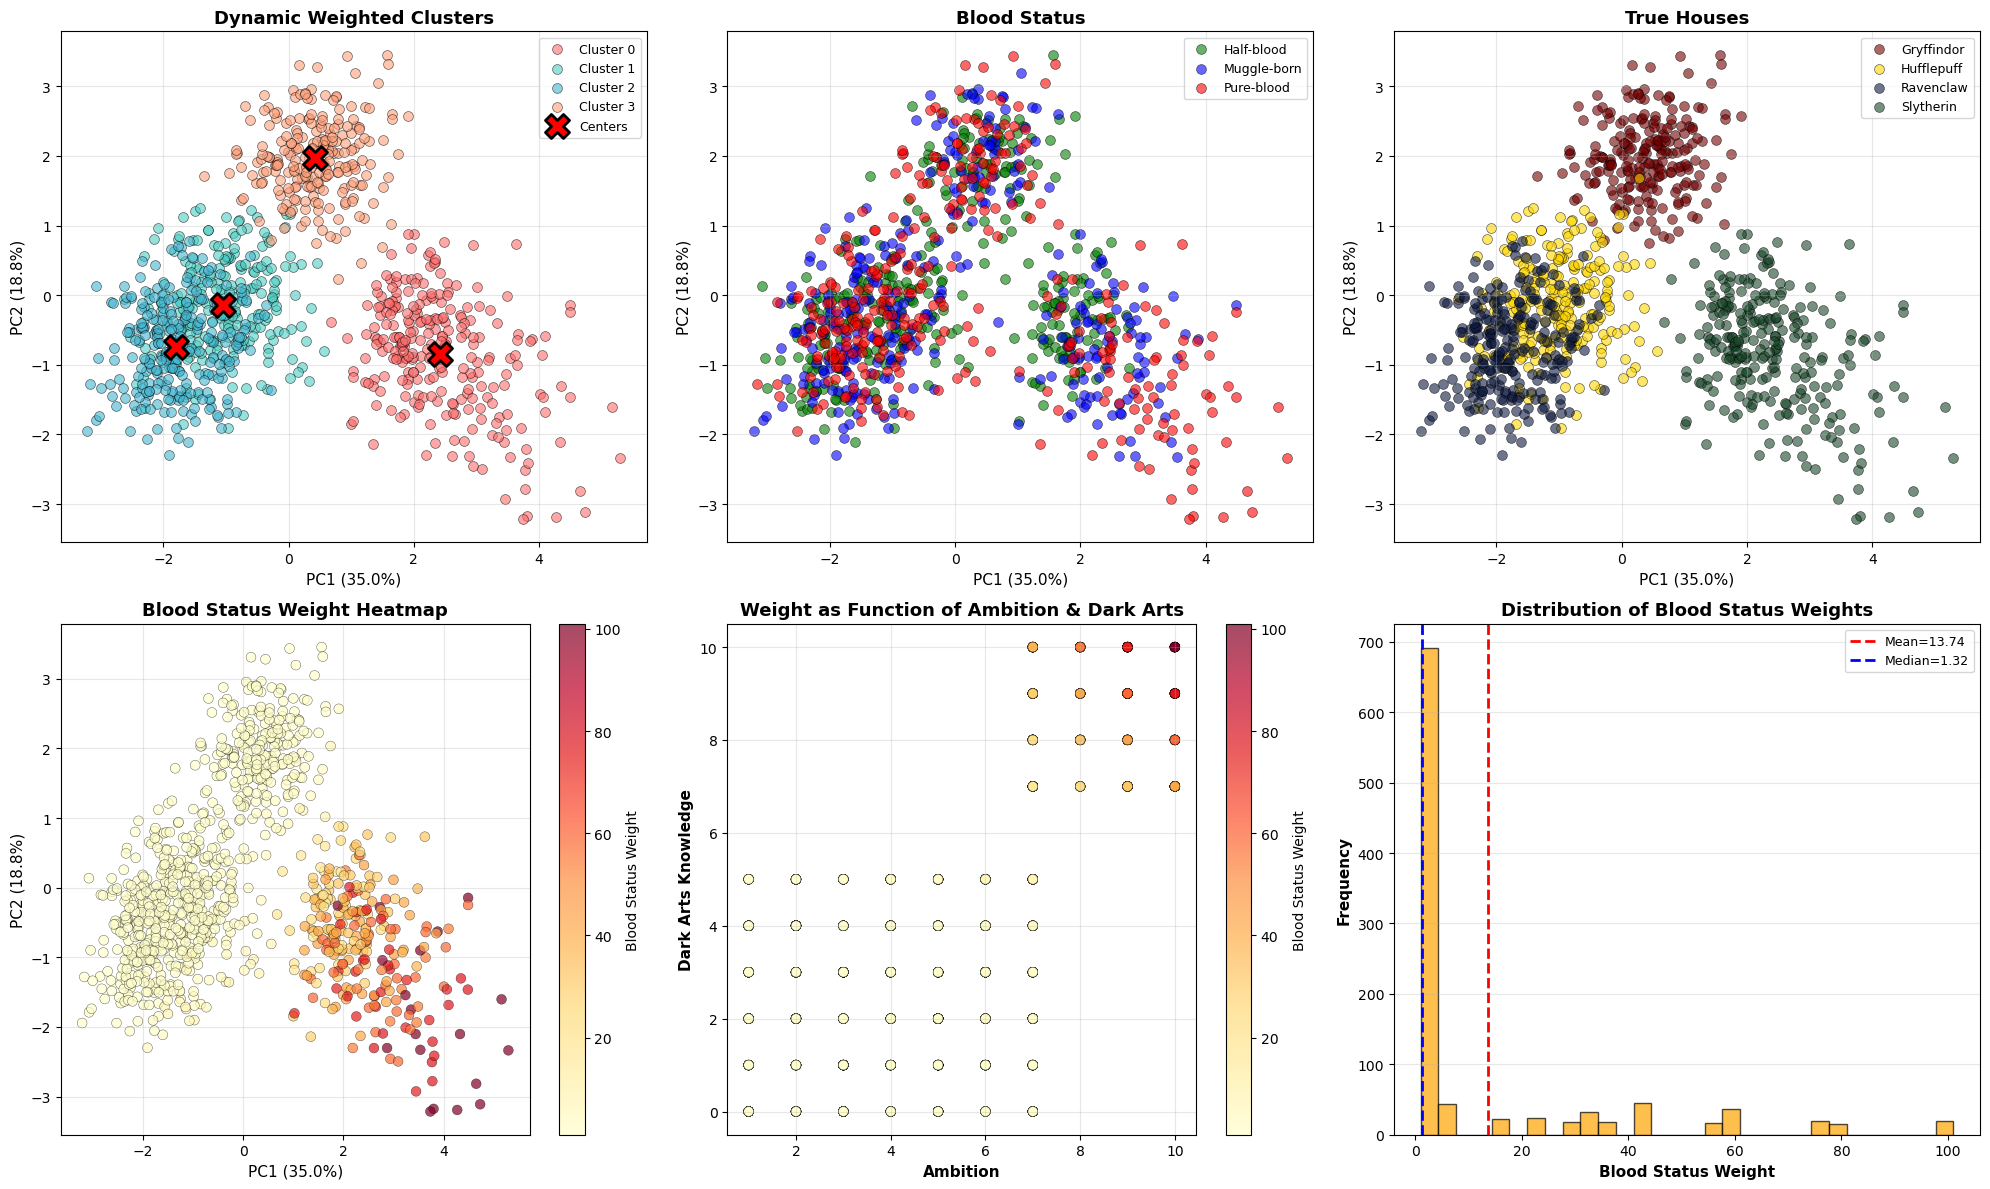


COMPARISON: STATIC vs DYNAMIC WEIGHTING

Static Weighted Clustering (Blood Status Weight: 500x):
  ARI vs Houses: -0.0005
  Silhouette Score: 1.0000

Dynamic Weighted Clustering (Weight: 1-101.0):
  ARI vs Houses: 0.9895
  Silhouette Score: 0.3041

------------------------------------------------------------
INTERPRETATION:
------------------------------------------------------------
Dynamic weighting with exponential amplification:
  • Base weight: 1.0, Scaling: 100.0, Power: 2.5
  • Formula: weight = 1 + 100 × (ambition × dark_arts)^2.5
  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status weight DRAMATICALLY increases
  • Students with MEDIUM values → Blood Status weight moderately increases
  • Students with LOW Ambition + LOW Dark Arts → Blood Status barely matters
  • The power term (2.5) creates exponential amplification for high values

Check the 'Weight as Function' plot to see the dramatic non-linear effect!

To adjust the effect:
  • Increase 'scaling_factor' (e.g

In [131]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)

# Prepare features
cluster_features_dynamic = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                            'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                            'Dueling Skills', 'Creativity']

X_dynamic = df[cluster_features_dynamic].values

# Extract Ambition and Dark Arts Knowledge (indices 4 and 5)
ambition = X_dynamic[:, 4]
dark_arts = X_dynamic[:, 5]

# Normalize Ambition and Dark Arts to [0, 1] range
ambition_norm = (ambition - ambition.min()) / (ambition.max() - ambition.min())
dark_arts_norm = (dark_arts - dark_arts.min()) / (dark_arts.max() - dark_arts.min())

# Create dynamic weight for Blood Status based on Ambition and Dark Arts
# Weight formula: base_weight + scaling_factor * (ambition_norm * dark_arts_norm)^power
base_weight = 1.0  # Minimum weight
scaling_factor = 100.0  # Maximum additional weight (increased from 50)
power = 2.5  # Exponent to amplify high values (makes the effect non-linear)

# Calculate per-instance blood status weight
# High ambition AND high dark arts → MUCH higher blood status weight
# The power term makes high values exponentially more important
blood_status_weights = base_weight + scaling_factor * ((ambition_norm * dark_arts_norm) ** power)

print(f"\nBase Blood Status Weight: {base_weight}")
print(f"Maximum Blood Status Weight: {base_weight + scaling_factor}")
print(f"Power Factor: {power} (higher = more dramatic effect for high values)")
print(f"\nBlood Status Weight Statistics:")
print(f"  Min:    {blood_status_weights.min():.2f}")
print(f"  Mean:   {blood_status_weights.mean():.2f}")
print(f"  Median: {np.median(blood_status_weights):.2f}")
print(f"  Max:    {blood_status_weights.max():.2f}")

# Show distribution of weights
print(f"\nWeight Distribution by Ambition & Dark Arts Levels:")
print("-" * 60)
for amb_threshold, amb_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
    for dark_threshold, dark_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
        mask = (ambition >= amb_threshold) & (dark_arts >= dark_threshold)
        if mask.sum() > 0:
            avg_weight = blood_status_weights[mask].mean()
            count = mask.sum()
            print(f"  {amb_label:6s} Ambition + {dark_label:6s} Dark Arts: "
                  f"Avg Weight = {avg_weight:5.2f} (n={count:3d})")
        if amb_threshold == 0 or dark_threshold == 0:
            break
    if amb_threshold == 0:
        break

# Create weighted feature matrix
X_dynamic_weighted = X_dynamic.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_dynamic_weighted[:, 0] = X_dynamic[:, 0] * blood_status_weights

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means
print("\nApplying dynamic weighted K-means with 4 clusters...")
kmeans_dynamic = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)

# Calculate metrics
silhouette_dynamic = silhouette_score(X_dynamic_scaled, clusters_dynamic)
ari_dynamic = adjusted_rand_score(df['House'], clusters_dynamic)

print(f"\nDynamic Weighted Clustering Metrics:")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")
print(f"  Adjusted Rand Index (vs Houses): {ari_dynamic:.4f}")

# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights

# Show cluster distribution
print("\n" + "-"*60)
print("Dynamic Cluster Distribution:")
print("-"*60)
unique_clusters_d, cluster_counts_d = np.unique(clusters_dynamic, return_counts=True)
for cluster, count in zip(unique_clusters_d, cluster_counts_d):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Dynamic Clusters vs Blood Status
print("\n" + "-"*60)
print("Dynamic Cluster vs Blood Status:")
print("-"*60)
crosstab_blood_d = pd.crosstab(df['Dynamic_Cluster'], df['Blood Status'], margins=True)
print(crosstab_blood_d)

# Cross-tabulation: Dynamic Clusters vs Houses
print("\n" + "-"*60)
print("Dynamic Cluster vs House:")
print("-"*60)
crosstab_house_d = pd.crosstab(df['Dynamic_Cluster'], df['House'], margins=True)
print(crosstab_house_d)

# Analyze clusters with high blood status weight
print("\n" + "-"*60)
print("Average Blood Status Weight by Cluster:")
print("-"*60)
for cluster in sorted(df['Dynamic_Cluster'].unique()):
    cluster_mask = df['Dynamic_Cluster'] == cluster
    avg_weight = df.loc[cluster_mask, 'Blood_Status_Weight'].mean()
    avg_ambition = df.loc[cluster_mask, 'Ambition'].mean()
    avg_dark_arts = df.loc[cluster_mask, 'Dark Arts Knowledge'].mean()
    print(f"  Cluster {cluster}: Weight={avg_weight:5.2f}, "
          f"Ambition={avg_ambition:.2f}, Dark Arts={avg_dark_arts:.2f}")

# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)

ax1.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('Dynamic Weighted Clusters', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax3.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Colored by Blood Status Weight (heatmap style)
ax4 = plt.subplot(2, 3, 4)
scatter = ax4.scatter(X_pca_dynamic[:, 0], X_pca_dynamic[:, 1],
                     c=blood_status_weights,
                     cmap='YlOrRd',
                     s=50,
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Blood Status Weight', fontsize=10)
ax4.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax4.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax4.set_title('Blood Status Weight Heatmap', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Ambition vs Dark Arts colored by Blood Status Weight
ax5 = plt.subplot(2, 3, 5)
scatter5 = ax5.scatter(ambition, dark_arts,
                      c=blood_status_weights,
                      cmap='YlOrRd',
                      s=50,
                      alpha=0.7,
                      edgecolors='black',
                      linewidth=0.3)
cbar5 = plt.colorbar(scatter5, ax=ax5)
cbar5.set_label('Blood Status Weight', fontsize=10)
ax5.set_xlabel('Ambition', fontsize=11, fontweight='bold')
ax5.set_ylabel('Dark Arts Knowledge', fontsize=11, fontweight='bold')
ax5.set_title('Weight as Function of Ambition & Dark Arts', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Weight distribution histogram
ax6 = plt.subplot(2, 3, 6)
ax6.hist(blood_status_weights, bins=30, color='orange', edgecolor='black', alpha=0.7)
ax6.axvline(blood_status_weights.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={blood_status_weights.mean():.2f}')
ax6.axvline(np.median(blood_status_weights), color='blue', linestyle='--', linewidth=2, label=f'Median={np.median(blood_status_weights):.2f}')
ax6.set_xlabel('Blood Status Weight', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6.set_title('Distribution of Blood Status Weights', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# COMPARISON
print("\n" + "="*60)
print("COMPARISON: STATIC vs DYNAMIC WEIGHTING")
print("="*60)

if 'Weighted_Cluster' in df.columns:
    print(f"\nStatic Weighted Clustering (Blood Status Weight: {blood_status_weight}x):")
    print(f"  ARI vs Houses: {ari_weighted:.4f}")
    print(f"  Silhouette Score: {silhouette_weighted:.4f}")

print(f"\nDynamic Weighted Clustering (Weight: 1-{base_weight + scaling_factor}):")
print(f"  ARI vs Houses: {ari_dynamic:.4f}")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")

print("\n" + "-"*60)
print("INTERPRETATION:")
print("-"*60)
print("Dynamic weighting with exponential amplification:")
print(f"  • Base weight: {base_weight}, Scaling: {scaling_factor}, Power: {power}")
print("  • Formula: weight = 1 + 100 × (ambition × dark_arts)^2.5")
print("  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status weight DRAMATICALLY increases")
print("  • Students with MEDIUM values → Blood Status weight moderately increases")
print("  • Students with LOW Ambition + LOW Dark Arts → Blood Status barely matters")
print("  • The power term (2.5) creates exponential amplification for high values")
print("\nCheck the 'Weight as Function' plot to see the dramatic non-linear effect!")
print("\nTo adjust the effect:")
print("  • Increase 'scaling_factor' (e.g., 150, 200) for even higher max weights")
print("  • Increase 'power' (e.g., 3, 4) for more extreme amplification of high values")
print("  • Decrease 'power' (e.g., 1.5, 2) for more gradual effect")